# Module 4A — Transformer Optimization (Beginner Expanded)
## Architecture Bottlenecks, Attention Memory, and FlashAttention

This notebook is an expanded, beginner-friendly version of the original Module 4A notes.  
It is designed for someone who is **new to transformer optimization** but wants to build a real systems understanding for:

- LLM inference and training interviews,
- performance engineering discussions,
- and later work on CUDA kernels and optimized attention backends.

## Learning objectives

By the end of this notebook, you should be able to explain:

1. **What a transformer block is doing**
2. **Why attention becomes expensive**
3. **Why the naive implementation stresses GPU memory**
4. **What FlashAttention changes**
5. **Why FlashAttention is exact, not approximate**
6. **Why the GPU implementation is fast even if a Python teaching implementation is not**

## How to use this notebook

This notebook mixes:

- **conceptual explanations** in Markdown,
- **small runnable NumPy / PyTorch examples**,
- **visuals and plots**,
- and **interview-oriented summaries**.

A good beginner workflow is:

1. Read a Markdown section slowly.
2. Run the code cell right after it.
3. Look at the output and connect it back to the ideas.
4. Do not worry about mastering every symbol on the first pass.

## What changed relative to the original notes

Compared with the earlier version, this notebook adds:

- more intuition before formulas,
- more explanation of tensor shapes,
- a small toy attention example,
- a worked example of **online softmax**,
- clearer separation between **algorithmic idea** and **GPU kernel implementation**,
- and beginner-friendly interview notes.

## Source philosophy

The concepts here are grounded in:

- the original Transformer paper,
- the FlashAttention and FlashAttention-2 papers,
- official PyTorch SDPA documentation,
- and official NVIDIA CUDA / WSL guidance.

A full reference list appears at the end.


In [1]:
# Core imports used throughout the notebook.
# We keep the dependency set intentionally small so the notebook runs in:
# - GitHub / VS Code
# - Google Colab
# - a local Python environment
# - or WSL2 on your HP desktop

import math
import time
import platform
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

# Plot settings that render cleanly in both GitHub and VS Code.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

# Nicer NumPy printing for small educational examples.
np.set_printoptions(precision=4, suppress=True)

print("Python platform:", platform.platform())
print("NumPy version:", np.__version__)
print("Environment initialized.")


Matplotlib is building the font cache; this may take a moment.


Python platform: Linux-4.4.0-x86_64-with-glibc2.41
NumPy version: 2.3.5
Environment initialized.


# 1. Big picture: why this module matters

Modern LLM systems are built around **transformer blocks**.  
If you want to work on:

- LLM training infrastructure,
- LLM inference / serving,
- model efficiency,
- or GPU kernel optimization,

then attention is one of the first places where **math** and **systems** meet.

That is why this module matters.

## One-sentence summary

The key lesson of Module 4A is:

> The attention formula is simple, but the **way it is executed on hardware** determines whether it is practical at scale.

## A beginner mental model

Think of a transformer as repeating the same high-level recipe:

1. take the current hidden representation,
2. let each token look at other relevant tokens through attention,
3. mix information,
4. run an MLP to transform features,
5. repeat this many times.

The attention part is powerful because it lets each token gather context from the entire sequence.  
But that same flexibility is what makes it expensive.

## Where this shows up in real LLM work

You will hear people say things like:

- "attention is memory-bound,"
- "the score matrix explodes with sequence length,"
- "FlashAttention reduces HBM traffic,"
- "PyTorch SDPA dispatches to an optimized backend,"

and this notebook is meant to make those statements feel concrete rather than mysterious.


# 2. Transformer architecture deep dive

The core scaled dot-product attention equation from the Transformer paper is

$$
\operatorname{Attention}(Q, K, V)
=
\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

where:

- $Q \in \mathbb{R}^{N \times d_k}$ are the **queries**
- $K \in \mathbb{R}^{N \times d_k}$ are the **keys**
- $V \in \mathbb{R}^{N \times d_v}$ are the **values**
- $N$ is the sequence length
- $d_k$ is the key / query head dimension

## What do queries, keys, and values mean intuitively?

A beginner-friendly way to think about them:

- A **query** asks: "What kind of information am I looking for?"
- A **key** says: "What kind of information do I contain?"
- A **value** is the actual information that gets mixed into the output.

The attention score between a query row and a key row says how relevant one token is to another.

## Anatomy of a decoder-style transformer block

A modern decoder-only LLM block usually looks like:

1. **Input residual stream**
2. **LayerNorm**
3. **Multi-head self-attention**
4. **Residual add**
5. **LayerNorm**
6. **MLP / feed-forward network**
7. **Residual add**

The block does not replace the old representation outright.  
Instead, it adds useful updates to the residual stream.

## Why multi-head attention exists

A single attention pattern can only focus in one "style" at a time.

Multiple heads let the model learn different interaction patterns in parallel, for example:

- local syntax,
- long-range references,
- entity tracking,
- or structural patterns in code.

For systems work, a crucial detail is that more heads also change the memory layout and kernel behavior.


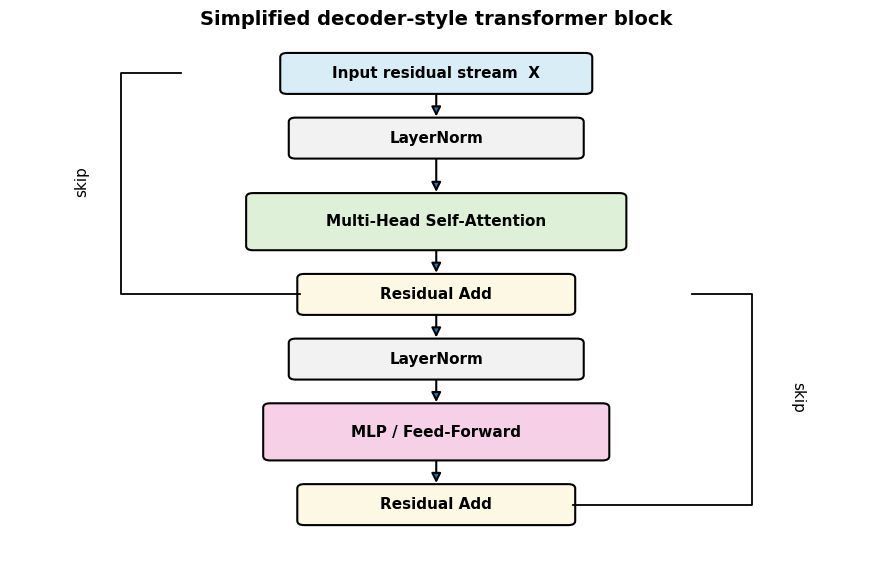

In [2]:
# Visual 1: a simplified pre-norm decoder block.
# This picture is intentionally schematic. Its purpose is to anchor the ideas,
# not to mirror every implementation detail used in every production LLM.

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

def box(x, y, w, h, text, color):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5,
        facecolor=color,
        edgecolor="black"
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
    )

def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.5,
        )
    )

box(3.2, 8.9, 3.6, 0.7, "Input residual stream  X", "#d9edf7")
box(3.3, 7.7, 3.4, 0.7, "LayerNorm", "#f2f2f2")
box(2.8, 6.0, 4.4, 1.0, "Multi-Head Self-Attention", "#dff0d8")
box(3.4, 4.8, 3.2, 0.7, "Residual Add", "#fcf8e3")
box(3.3, 3.6, 3.4, 0.7, "LayerNorm", "#f2f2f2")
box(3.0, 2.1, 4.0, 1.0, "MLP / Feed-Forward", "#f5d0e6")
box(3.4, 0.9, 3.2, 0.7, "Residual Add", "#fcf8e3")

arrow(5.0, 8.9, 5.0, 8.4)
arrow(5.0, 7.7, 5.0, 7.0)
arrow(5.0, 6.0, 5.0, 5.5)
arrow(5.0, 4.8, 5.0, 4.3)
arrow(5.0, 3.6, 5.0, 3.1)
arrow(5.0, 2.1, 5.0, 1.6)

# Residual skip path around attention
ax.plot([2.0, 1.3, 1.3, 3.4], [9.25, 9.25, 5.15, 5.15], color="black", linewidth=1.3)
ax.text(0.75, 7.25, "skip", rotation=90, va="center")

# Residual skip path around MLP
ax.plot([8.0, 8.7, 8.7, 6.6], [5.15, 5.15, 1.25, 1.25], color="black", linewidth=1.3)
ax.text(9.15, 3.25, "skip", rotation=270, va="center")

ax.set_title("Simplified decoder-style transformer block", fontsize=14, weight="bold")
plt.show()


# 3. Attention intuition before optimization

Before we optimize attention, it is worth slowing down and seeing what the operator does.

## What happens in one row of attention?

Take one query row $q_i$.

1. Compare it to every key row to get similarity scores.
2. Turn those scores into probabilities with softmax.
3. Use those probabilities to take a weighted average of the value rows.

So one query row produces one new output row.

## Why the $QK^\top$ multiplication matters

If $Q$ has shape $N \times d$ and $K$ has shape $N \times d$, then

$$
QK^\top \in \mathbb{R}^{N \times N}
$$

That means every query token is compared with every key token.

This is the source of the familiar **quadratic** scaling in sequence length.

## Tiny toy example

The next cell builds a tiny example with four tokens.

Do not treat the numbers as a real language model.  
They are just small vectors chosen so the behavior is easy to inspect.


Scaled attention scores:
[[ 1.1597  1.0324 -0.594  -0.6647]
 [ 1.0324  0.9192 -0.5374 -0.5869]
 [-0.594  -0.5374  0.7354  0.099 ]
 [-0.6647 -0.5869  0.099   0.5162]]

Attention probabilities (rows sum to 1):
[[0.4515 0.3975 0.0782 0.0728]
 [0.4349 0.3884 0.0905 0.0861]
 [0.1276 0.135  0.4822 0.2552]
 [0.1336 0.1444 0.2868 0.4352]]

Output vectors:
[[0.7695 0.1577 0.0728]
 [0.7457 0.1682 0.0861]
 [0.2356 0.5092 0.2552]
 [0.2492 0.3156 0.4352]]


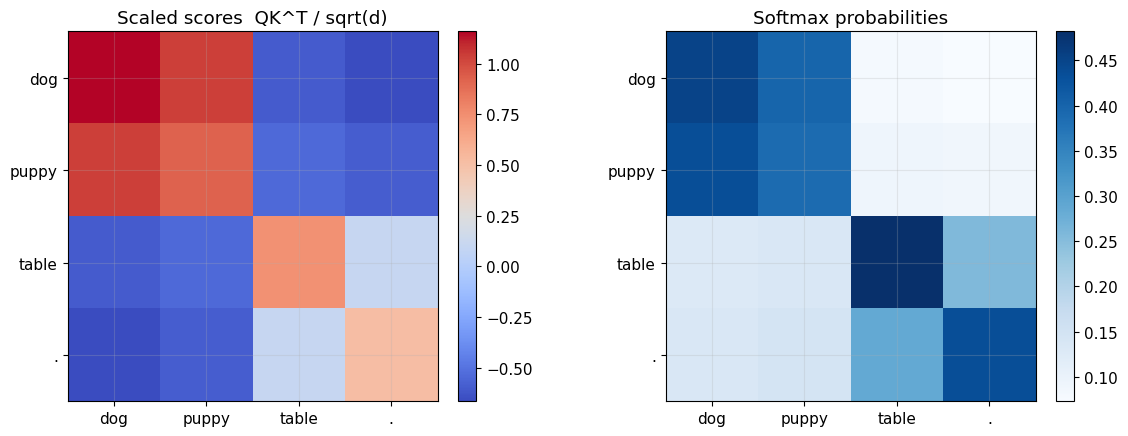

How the token 'dog' distributes its attention:
  ->    dog: 0.4515
  ->  puppy: 0.3975
  ->  table: 0.0782
  ->      .: 0.0728


In [3]:
# Toy example: show how one token can attend more strongly to semantically similar tokens.
# We use tiny 2D vectors so the scores are easy to read.

tokens = ["dog", "puppy", "table", "."]
Q = np.array([
    [1.0, 0.8],   # dog-like
    [0.9, 0.7],   # puppy-like, similar to dog
    [-1.0, 0.2],  # furniture-like, deliberately different
    [-0.3, -0.8], # punctuation / other
], dtype=np.float64)

# For a toy self-attention picture, we reuse the same vectors as keys.
K = Q.copy()

# Values can be thought of as the information to mix together.
V = np.array([
    [1.0, 0.0, 0.0],   # animal information
    [0.8, 0.2, 0.0],   # similar animal information
    [0.0, 1.0, 0.0],   # furniture information
    [0.0, 0.0, 1.0],   # punctuation / boundary information
], dtype=np.float64)

def stable_softmax(x, axis=-1):
    # Numerically stable softmax:
    # subtract the row maximum before exponentiating.
    x_max = np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x - x_max)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

scale = 1 / math.sqrt(Q.shape[1])
scores = Q @ K.T * scale
probs = stable_softmax(scores, axis=1)
out = probs @ V

print("Scaled attention scores:")
print(scores)
print("\nAttention probabilities (rows sum to 1):")
print(probs)
print("\nOutput vectors:")
print(out)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].imshow(scores, cmap="coolwarm")
axes[0].set_title("Scaled scores  QK^T / sqrt(d)")
axes[0].set_xticks(range(len(tokens)))
axes[0].set_yticks(range(len(tokens)))
axes[0].set_xticklabels(tokens)
axes[0].set_yticklabels(tokens)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(probs, cmap="Blues")
axes[1].set_title("Softmax probabilities")
axes[1].set_xticks(range(len(tokens)))
axes[1].set_yticks(range(len(tokens)))
axes[1].set_xticklabels(tokens)
axes[1].set_yticklabels(tokens)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

dog_row = probs[0]
print("How the token 'dog' distributes its attention:")
for tok, p in zip(tokens, dog_row):
    print(f"  -> {tok:>6s}: {p:.4f}")


# 4. Where the bottleneck comes from

The attention formula is compact, but the naive implementation can be expensive.

## The core issue

For one head, the naive implementation often materializes:

$$
S = \frac{QK^\top}{\sqrt{d_k}}
$$

and sometimes also the probability matrix

$$
P = \operatorname{softmax}(S)
$$

Both are $N \times N$ matrices.

If $N$ is small, that is fine.  
If $N$ becomes large, those matrices become expensive to:

- allocate,
- write to high-bandwidth memory (HBM),
- read back,
- and possibly keep around for backward pass.

## Why memory traffic matters so much on GPUs

A useful hardware analogy:

- **registers / shared memory / on-chip SRAM** are like ingredients on the kitchen counter  
  (small but fast)
- **HBM / global memory** is like the pantry across the room  
  (big but slower to access)

A fast kernel tries to reuse data while it is still "on the counter" instead of walking back to the pantry over and over.

That is exactly the spirit of FlashAttention.

## Important beginner lesson

A bottleneck is not only about FLOPs.

Two implementations can compute the same math, but one can be much slower because it moves data around less efficiently.


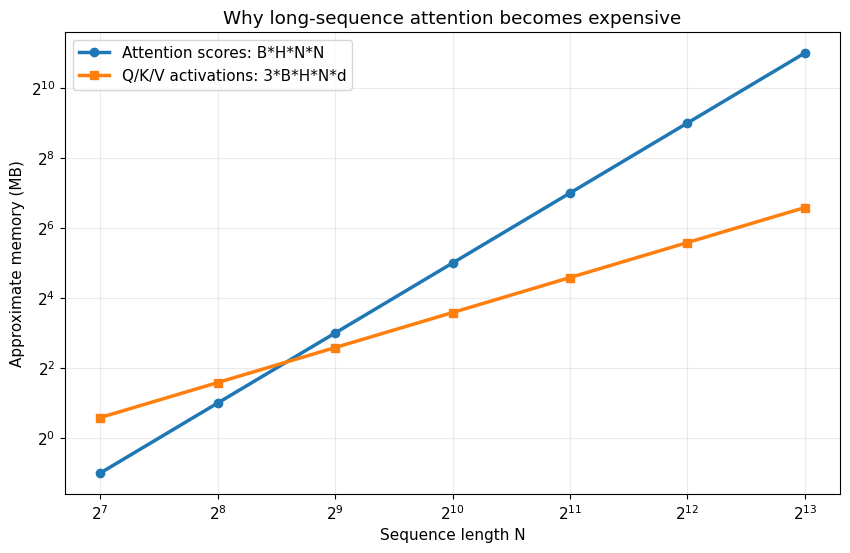

For B=1, H=16, N=4096, fp16/bf16-style scores need about 512.0 MB.


In [4]:
# Plot how the score-matrix memory scales with sequence length.
# This is not a profiler trace. It is a simple "systems intuition" plot.

seq_lens = np.array([128, 256, 512, 1024, 2048, 4096, 8192], dtype=np.int64)

B = 1               # batch size
H = 16              # number of attention heads
d_head = 128        # head dimension
dtype_bytes = 2     # fp16 / bf16 intuition

# Memory for one N x N score tensor across all heads.
score_mem_mb = B * H * seq_lens * seq_lens * dtype_bytes / (1024 ** 2)

# Rough Q/K/V activation memory.
qkv_mem_mb = 3 * B * H * seq_lens * d_head * dtype_bytes / (1024 ** 2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(seq_lens, score_mem_mb, marker="o", linewidth=2.5, label="Attention scores: B*H*N*N")
ax.plot(seq_lens, qkv_mem_mb, marker="s", linewidth=2.5, label="Q/K/V activations: 3*B*H*N*d")

ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("Sequence length N")
ax.set_ylabel("Approximate memory (MB)")
ax.set_title("Why long-sequence attention becomes expensive")
ax.legend()
plt.show()

# Print one concrete example to make the plot feel tangible.
N = 4096
score_mem_4096 = B * H * N * N * dtype_bytes / (1024 ** 2)
print(f"For B={B}, H={H}, N={N}, fp16/bf16-style scores need about {score_mem_4096:.1f} MB.")


# 5. Naive attention: the straightforward algorithm

The naive implementation is conceptually simple:

1. compute the full score matrix,
2. apply row-wise softmax,
3. multiply by $V$.

This section implements that reference version.

## Why write it ourselves?

Because later, when we introduce FlashAttention, it helps to compare against a simple baseline that we completely understand.

## A caution for beginners

The naive version is **not wrong**.  
It is the natural first implementation.

FlashAttention exists because the naive execution schedule becomes inefficient at large sequence lengths.


In [5]:
# Reference implementation of standard scaled dot-product attention.
# This version is intentionally simple and heavily commented.

def naive_attention(q, k, v, scale=None, causal=False):
    """
    Standard scaled dot-product attention.

    Parameters
    ----------
    q, k : np.ndarray of shape (N, d_head)
        Query and key matrices for one attention head.
    v : np.ndarray of shape (N, d_value)
        Value matrix for one attention head.
    scale : float or None
        If None, use the usual 1 / sqrt(d_head) scaling.
    causal : bool
        If True, token i cannot attend to tokens j > i.

    Returns
    -------
    out : np.ndarray of shape (N, d_value)
        Attention output.
    """

    # The standard transformer scaling reduces score magnitude,
    # which helps softmax remain better behaved.
    if scale is None:
        scale = 1.0 / math.sqrt(q.shape[1])

    # Step 1: build the full score matrix.
    scores = (q @ k.T) * scale

    # Step 2: apply a causal mask if requested.
    if causal:
        # Upper triangular entries above the main diagonal are invalid.
        mask = np.triu(np.ones_like(scores, dtype=bool), k=1)
        scores = np.where(mask, -np.inf, scores)

    # Step 3: row-wise stable softmax.
    probs = stable_softmax(scores, axis=1)

    # Step 4: weighted sum of values.
    out = probs @ v
    return out


# 6. The key mathematical trick behind FlashAttention: online softmax

FlashAttention needs to avoid storing the full $N \times N$ score matrix.

That creates a challenge:

- softmax over a row normally wants access to the **whole row**
- but tiled processing sees only one chunk of the row at a time

So how can we stay exact?

## The idea

For each query row, FlashAttention keeps a small set of running statistics while it streams over key/value tiles:

- the running row maximum $m$
- the running normalization term $\ell$
- the running output accumulator

When a new block of scores arrives, those statistics are updated in a numerically stable way.

## Why this matters

This is the heart of FlashAttention:

> compute softmax **incrementally** without ever materializing the full row of probabilities.

The next cell shows this idea on a single row before we move to the full tiled algorithm.


Row scores: [ 1.2  0.3  2.7 -1.4  1.9  0.8]
Full softmax:   [0.1157 0.047  0.5183 0.0086 0.2329 0.0775]
Online softmax: [0.1157 0.047  0.5183 0.0086 0.2329 0.0775]
Max abs diff: 1.1102230246251565e-16


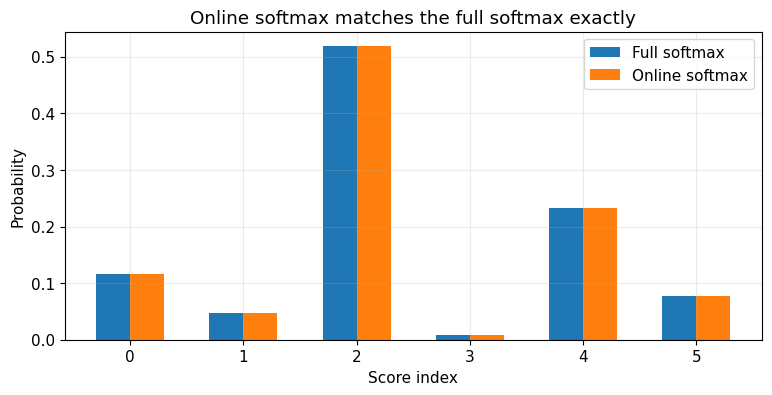

In [6]:
# Demonstration: online softmax on one row of scores split into blocks.
# This is one of the most important ideas in FlashAttention.

row_scores = np.array([1.2, 0.3, 2.7, -1.4, 1.9, 0.8], dtype=np.float64)
blocks = [row_scores[:3], row_scores[3:]]

full_softmax = stable_softmax(row_scores)

def online_softmax_from_blocks(block_list):
    """
    Compute softmax exactly while seeing scores only block by block.

    Returns the final (m, l) statistics where:
    - m is the global max score
    - l is the sum of exp(score - m) over the full row
    """
    m = -np.inf
    l = 0.0

    for block in block_list:
        block_max = np.max(block)
        block_sum = np.sum(np.exp(block - block_max))

        new_m = max(m, block_max)

        # Rescale both the old contribution and the new block contribution
        # into the same exponent reference frame.
        old_term = math.exp(m - new_m) * l if np.isfinite(m) else 0.0
        new_term = math.exp(block_max - new_m) * block_sum

        l = old_term + new_term
        m = new_m

    return m, l

m, l = online_softmax_from_blocks(blocks)
online_softmax = np.exp(row_scores - m) / l

print("Row scores:", row_scores)
print("Full softmax:  ", full_softmax)
print("Online softmax:", online_softmax)
print("Max abs diff:", np.max(np.abs(full_softmax - online_softmax)))

assert np.allclose(full_softmax, online_softmax, atol=1e-12)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(len(row_scores)) - 0.15, full_softmax, width=0.3, label="Full softmax")
ax.bar(np.arange(len(row_scores)) + 0.15, online_softmax, width=0.3, label="Online softmax")
ax.set_xticks(range(len(row_scores)))
ax.set_xlabel("Score index")
ax.set_ylabel("Probability")
ax.set_title("Online softmax matches the full softmax exactly")
ax.legend()
plt.show()


# 7. FlashAttention: the algorithmic idea

Now we are ready for the real optimization idea.

## Standard attention schedule

The naive schedule is roughly:

1. build all scores,
2. build all probabilities,
3. multiply by all values.

That schedule is simple but memory-hungry.

## FlashAttention schedule

FlashAttention changes the **execution order**:

- process a small block of query rows,
- stream over key/value blocks,
- update online softmax statistics,
- update the output accumulator,
- never store the full $N \times N$ score matrix in HBM.

## What changes and what does not

### What changes
- the **schedule**
- the **memory traffic**
- the **working set size**
- the **hardware efficiency**

### What does not change
- the underlying exact dense attention result

That is why FlashAttention is called an **exact** attention algorithm, not an approximation.

## A useful beginner rephrase

You can think of FlashAttention as:

> "Do the same math, but do it in a way the GPU likes much more."


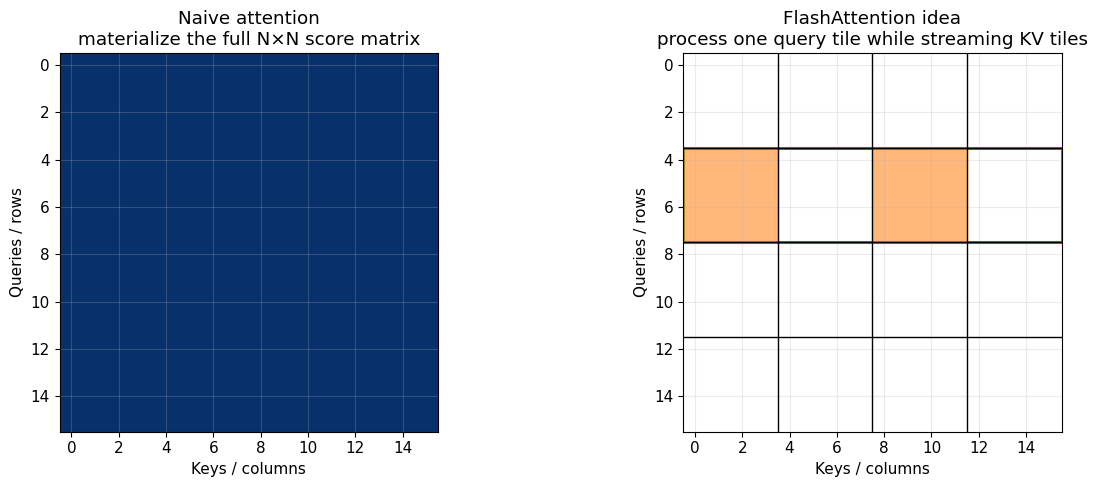

In [7]:
# Visual: full-matrix materialization versus tiled processing.
# The right panel shows the intuition: we only need a small active tile at a time.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: naive full matrix
ax = axes[0]
full = np.ones((16, 16))
ax.imshow(full, cmap="Blues", vmin=0, vmax=1)
ax.set_title("Naive attention\nmaterialize the full N×N score matrix")
ax.set_xlabel("Keys / columns")
ax.set_ylabel("Queries / rows")

# Right: tiled processing
ax = axes[1]
ax.imshow(np.zeros((16, 16)), cmap="Greys", vmin=0, vmax=1)

# Draw tile boundaries.
for t in [4, 8, 12]:
    ax.axhline(t - 0.5, color="black", linewidth=1.0)
    ax.axvline(t - 0.5, color="black", linewidth=1.0)

# Highlight one query tile and two key/value tiles.
query_block = Rectangle((-0.5, 4 - 0.5), 16, 4, fill=False, linewidth=2.2, edgecolor="tab:green")
kv_tile_1 = Rectangle((0 - 0.5, 4 - 0.5), 4, 4, fill=True, alpha=0.55, color="tab:orange")
kv_tile_2 = Rectangle((8 - 0.5, 4 - 0.5), 4, 4, fill=True, alpha=0.55, color="tab:orange")

ax.add_patch(query_block)
ax.add_patch(kv_tile_1)
ax.add_patch(kv_tile_2)

ax.set_title("FlashAttention idea\nprocess one query tile while streaming KV tiles")
ax.set_xlabel("Keys / columns")
ax.set_ylabel("Queries / rows")

plt.tight_layout()
plt.show()


# 8. A teaching implementation of FlashAttention (NumPy / CPU)

The next function is the most important code in this notebook.

It is **not** a production GPU kernel.

It is a **reference implementation** whose goals are:

- clarity,
- correctness,
- and intuition.

## What this implementation demonstrates

It shows how to:

- process attention in tiles,
- maintain running row maxima,
- maintain running normalization terms,
- and update the output accumulator without materializing the full score matrix.

## What it does *not* demonstrate

It does **not** demonstrate:

- warp scheduling,
- shared memory layout,
- register pressure,
- tensor cores,
- occupancy tuning,
- or fused CUDA kernel performance.

Those are kernel-engineering topics layered on top of the same core idea.


In [8]:
# FlashAttention-style reference implementation.
# This version is intentionally verbose and heavily commented for learning.

def flash_attention_reference(q, k, v, block_q=64, block_k=64, scale=None, causal=False):
    """
    FlashAttention-style exact attention reference implementation.

    This function demonstrates the algorithmic structure of FlashAttention:
    - process a tile of query rows,
    - stream over key/value tiles,
    - keep only a small working set,
    - use online softmax to stay exact.

    Parameters
    ----------
    q, k : np.ndarray of shape (N, d_head)
    v : np.ndarray of shape (N, d_value)
    block_q : int
        Number of query rows processed together.
    block_k : int
        Number of key/value rows streamed at a time.
    scale : float or None
        If None, use 1 / sqrt(d_head).
    causal : bool
        Whether to apply a causal mask.

    Returns
    -------
    out : np.ndarray of shape (N, d_value)
        Exact attention output.
    """

    if scale is None:
        scale = 1.0 / math.sqrt(q.shape[1])

    n = q.shape[0]
    d_value = v.shape[1]

    # We accumulate in float64 in this educational version
    # so numerical comparisons against the naive reference are very tight.
    out = np.zeros((n, d_value), dtype=np.float64)

    # Process one block of query rows at a time.
    for q_start in range(0, n, block_q):
        q_end = min(q_start + block_q, n)
        q_block = q[q_start:q_end]                          # shape: (BQ, d_head)
        q_block_size = q_end - q_start

        # Running statistics for each query row in the block.
        m = np.full(q_block_size, -np.inf, dtype=np.float64)   # running max
        l = np.zeros(q_block_size, dtype=np.float64)           # running softmax denominator
        acc = np.zeros((q_block_size, d_value), dtype=np.float64)  # running output numerator

        # Stream over K/V tiles.
        for k_start in range(0, n, block_k):
            k_end = min(k_start + block_k, n)
            k_block = k[k_start:k_end]                        # shape: (BK, d_head)
            v_block = v[k_start:k_end]                        # shape: (BK, d_value)

            # Compute scores only for the active query block and active key block.
            scores = (q_block @ k_block.T) * scale            # shape: (BQ, BK)

            # Apply causal masking if needed.
            if causal:
                q_positions = np.arange(q_start, q_end)[:, None]
                k_positions = np.arange(k_start, k_end)[None, :]
                scores = np.where(k_positions <= q_positions, scores, -np.inf)

            # Row-wise block max for numerical stability.
            block_m = np.max(scores, axis=1)

            # Exponentiate relative to the block max.
            exp_scores = np.exp(scores - block_m[:, None])

            # Zero out invalid entries explicitly.
            exp_scores = np.where(np.isfinite(scores), exp_scores, 0.0)

            # Sum over the current block.
            block_l = np.sum(exp_scores, axis=1)

            # Combine old stats and new block stats into a common reference frame.
            new_m = np.maximum(m, block_m)

            old_scale = np.exp(m - new_m)
            block_scale = np.exp(block_m - new_m)

            # Update the numerator accumulator:
            # old contribution + current block contribution
            acc = acc * old_scale[:, None] + (exp_scores @ v_block) * block_scale[:, None]

            # Update the denominator.
            l = l * old_scale + block_l * block_scale

            # Update the running max.
            m = new_m

        # Final normalization for this query tile.
        out[q_start:q_end] = acc / l[:, None]

    return out


In [9]:
# Correctness checks: the tiled version should match the naive version.
# We test several configurations, including causal masking.

np.random.seed(7)

test_cases = [
    (32, 16, 12, False),
    (32, 16, 12, True),
    (96, 32, 24, False),
    (96, 32, 24, True),
]

for n, d_head, d_value, causal in test_cases:
    q = np.random.randn(n, d_head).astype(np.float64)
    k = np.random.randn(n, d_head).astype(np.float64)
    v = np.random.randn(n, d_value).astype(np.float64)

    ref = naive_attention(q, k, v, causal=causal)
    flash = flash_attention_reference(q, k, v, block_q=32, block_k=32, causal=causal)

    max_abs_err = np.max(np.abs(ref - flash))
    mean_abs_err = np.mean(np.abs(ref - flash))

    print(
        f"n={n:>3d}, d_head={d_head:>2d}, d_value={d_value:>2d}, causal={str(causal):<5s} "
        f"| max_abs_err={max_abs_err:.3e} | mean_abs_err={mean_abs_err:.3e}"
    )

    assert max_abs_err < 1e-10

print("\nResult: the FlashAttention-style reference matches naive attention on all tests.")


n= 32, d_head=16, d_value=12, causal=False | max_abs_err=3.053e-16 | mean_abs_err=4.551e-17
n= 32, d_head=16, d_value=12, causal=True  | max_abs_err=3.331e-16 | mean_abs_err=4.368e-17
n= 96, d_head=32, d_value=24, causal=False | max_abs_err=6.661e-16 | mean_abs_err=6.496e-17
n= 96, d_head=32, d_value=24, causal=True  | max_abs_err=6.661e-16 | mean_abs_err=7.474e-17

Result: the FlashAttention-style reference matches naive attention on all tests.


/tmp/ipykernel_2793/2903252596.py:73: RuntimeWarning: invalid value encountered in subtract
  exp_scores = np.exp(scores - block_m[:, None])


# 9. Why the Python reference may be slower than the naive NumPy version

This is a very common beginner confusion.

You might run the two implementations above and notice:

- the naive version is short and uses large vectorized NumPy operations,
- the FlashAttention-style reference uses Python loops over blocks,
- so the tiled reference may actually run **slower on CPU in Python**.

That does **not** invalidate the FlashAttention idea.

## The key distinction

### Algorithmic idea
- tile the computation,
- reduce memory traffic,
- keep a small working set,
- use online softmax.

### Hardware implementation
- fuse operations,
- use shared memory and registers,
- reduce HBM reads / writes,
- choose a good thread / warp / block mapping,
- maximize occupancy.

FlashAttention wins when the tiled algorithm is mapped well to the GPU memory hierarchy.

That is why the papers and production kernels matter.


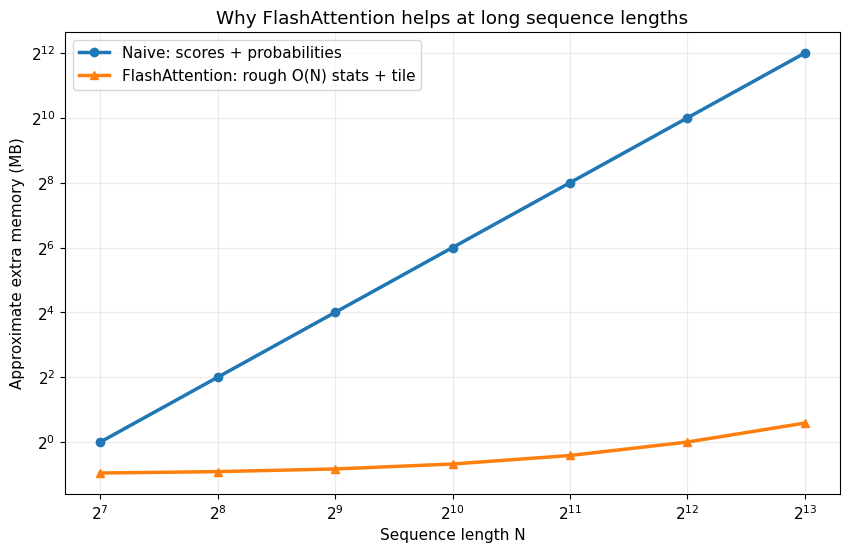

In [10]:
# Compare how the rough "extra intermediate memory" grows for naive attention
# versus a simplified FlashAttention-style working-set estimate.
# This is an intuition plot, not a formal cost model.

seq_lens = np.array([128, 256, 512, 1024, 2048, 4096, 8192], dtype=np.int64)
dtype_bytes = 2
B, H = 1, 16
block_q, block_k = 128, 128

# Naive intuition: score tensor + probability tensor.
naive_extra_mb = 2 * B * H * seq_lens * seq_lens * dtype_bytes / (1024 ** 2)

# FlashAttention intuition:
# - O(N) row stats
# - plus a fixed-size active tile / workspace
flash_stats_mb = B * H * seq_lens * 2 * 4 / (1024 ** 2)  # running max + running l in float32-ish terms
flash_tile_mb = np.full_like(seq_lens, B * H * block_q * block_k * dtype_bytes / (1024 ** 2), dtype=np.float64)
flash_extra_mb = flash_stats_mb + flash_tile_mb

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(seq_lens, naive_extra_mb, marker="o", linewidth=2.5, label="Naive: scores + probabilities")
ax.plot(seq_lens, flash_extra_mb, marker="^", linewidth=2.5, label="FlashAttention: rough O(N) stats + tile")

ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("Sequence length N")
ax.set_ylabel("Approximate extra memory (MB)")
ax.set_title("Why FlashAttention helps at long sequence lengths")
ax.legend()
plt.show()


# 10. What makes the real CUDA kernel fast?

The reference implementation above teaches the algorithm.  
The GPU kernel is fast because it combines that algorithm with hardware-aware engineering.

## The main reasons

### 1. Tiling fits the working set into fast memory
Active tiles of $Q$, $K$, and $V$ can be reused while they are still in on-chip memory.

### 2. The kernel avoids giant HBM intermediates
The full attention score matrix does not need to be stored and reloaded from HBM.

### 3. The kernel fuses multiple logical steps
Instead of launching many separate kernels and writing intermediate tensors between them, the optimized implementation does more work in one tightly scheduled kernel.

### 4. Work partitioning matters
FlashAttention-2 shows that once IO is improved, additional speed still depends on:
- good parallelism,
- less shared-memory communication,
- and lower non-matmul overhead.

## Beginner summary

A good mental progression is:

1. understand the math,
2. understand why the naive schedule is memory-hungry,
3. understand how tiling + online softmax changes the schedule,
4. then learn how real GPU kernels map that schedule onto hardware.


In [11]:
# Optional practical check with PyTorch SDPA.
# This cell runs on CPU-only systems too, but on a CUDA machine it may dispatch
# to an optimized backend depending on the environment and tensor properties.

try:
    import torch
    import torch.nn.functional as F
    torch_available = True
except Exception as e:
    torch_available = False
    torch_import_error = repr(e)

if not torch_available:
    print("PyTorch is not available in this environment.")
    print("Import error:", torch_import_error)
else:
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    # Use a small deterministic example so we can compare against our NumPy reference.
    torch.manual_seed(0)
    np.random.seed(0)

    N = 32
    d_head = 16
    d_value = 16

    q_np = np.random.randn(N, d_head).astype(np.float32)
    k_np = np.random.randn(N, d_head).astype(np.float32)
    v_np = np.random.randn(N, d_value).astype(np.float32)

    # NumPy reference
    ref_np = flash_attention_reference(q_np.astype(np.float64), k_np.astype(np.float64), v_np.astype(np.float64), causal=True)

    # PyTorch expects (batch, heads, seq, dim) here.
    device = "cuda" if torch.cuda.is_available() else "cpu"
    q_t = torch.tensor(q_np, device=device).unsqueeze(0).unsqueeze(0)
    k_t = torch.tensor(k_np, device=device).unsqueeze(0).unsqueeze(0)
    v_t = torch.tensor(v_np, device=device).unsqueeze(0).unsqueeze(0)

    out_t = F.scaled_dot_product_attention(
        q_t, k_t, v_t,
        attn_mask=None,
        dropout_p=0.0,
        is_causal=True
    )

    out_np = out_t.squeeze(0).squeeze(0).detach().cpu().numpy()
    max_abs_err = np.max(np.abs(out_np - ref_np))

    print("Device used:", device)
    print("Output shape:", tuple(out_t.shape))
    print("Max abs diff vs NumPy FlashAttention-style reference:", float(max_abs_err))

    # CPU float32 and NumPy float64 will not match bit-for-bit, so we use a looser threshold.
    assert max_abs_err < 1e-4

    if device == "cuda":
        print("\nOn CUDA, PyTorch may dispatch to an optimized SDPA backend when conditions permit.")


PyTorch version: 2.10.0+cpu
CUDA available: False
Device used: cpu
Output shape: (1, 1, 32, 16)
Max abs diff vs NumPy FlashAttention-style reference: 3.0413482754454435e-07



# 10A. From a teaching reference to an interview-ready GPU implementation

Up to this point, the notebook has shown the **algorithmic idea** behind FlashAttention.

That is the right first step for a beginner.  
But for **LLM inference / serving interviews**, it is even better if you can say:

1. **I understand the tiled, online-softmax idea**
2. **I implemented a small Triton tiled attention kernel**
3. **I validated it against a trusted reference**
4. **I benchmarked it against PyTorch SDPA on GPU**
5. **I also wrote a tiny forward-only CUDA kernel to prove I understand the low-level execution model**

That is exactly what the rest of this notebook adds.

## Why Triton first?

For interview preparation, Triton is a very practical middle ground:

- lower-level than plain PyTorch,
- much easier to read and modify than a full production CUDA/C++ extension,
- close to how real high-performance kernels are reasoned about,
- and directly relevant to modern inference systems work.

## Why still include a tiny CUDA kernel?

Because Triton helps you reason at the **tile / program** level, while a tiny CUDA kernel helps you reason at the **thread / block** level.

A strong interview story often needs both.

## A beginner mental model

Think of the progression like this:

- **NumPy reference**: "What math are we doing?"
- **Triton tiled kernel**: "How do we organize the work so the GPU memory system likes it?"
- **Tiny CUDA kernel**: "What are the threads and blocks literally doing?"

That progression is exactly what many inference interviews are testing.



# 10B. Runtime setup for the Triton lab

This notebook is meant to run in three modes:

## Mode 1 — real CUDA GPU
This is the main target for your HP desktop or Colab GPU:
- Triton compiles and runs on the GPU
- the benchmark cells run
- you can compare against PyTorch SDPA meaningfully

## Mode 2 — Triton interpreter mode
If a real CUDA GPU is not available, Triton provides an **interpreter mode** that executes Triton programs on the CPU using NumPy-like semantics.  
This is **not** a performance mode. It is a **correctness / debugging mode**.

That is extremely useful for learning because it lets us validate the kernel logic in environments without a GPU.

## Mode 3 — Numba CUDA simulator
Later in the notebook, the educational CUDA kernel uses Numba.  
Numba also provides a simulator mode so we can validate CUDA-kernel logic even without a GPU.

## Important honesty note

- **Correctness validation** can be done without a GPU using Triton interpreter mode and Numba's CUDA simulator.
- **Performance benchmarking** only makes sense on a real CUDA GPU.

That distinction matters in interviews. It shows you understand the difference between
"the code is logically correct" and "the code is actually fast on hardware."


In [ ]:

# Runtime detection and imports for the Triton section.
#
# Detailed note:
# - If a real CUDA GPU is available, we keep normal Triton execution.
# - If no CUDA GPU is available, we enable Triton's interpreter mode *before*
#   importing Triton. This lets us validate correctness on CPU.
# - We do not force interpreter mode on a real GPU machine because the goal
#   there is to compile and benchmark the real kernel.

import os
import sys
import math
import time

try:
    import torch
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    TORCH_IMPORT_ERROR = repr(e)

HAS_REAL_CUDA = bool(TORCH_AVAILABLE and torch.cuda.is_available())

# Enable Triton interpreter mode only when we do not have a real CUDA GPU.
# This must happen before importing Triton.
if not HAS_REAL_CUDA and "triton" not in sys.modules:
    os.environ.setdefault("TRITON_INTERPRET", "1")

try:
    import triton
    import triton.language as tl
    TRITON_AVAILABLE = True
    TRITON_IMPORT_ERROR = None
except Exception as e:
    TRITON_AVAILABLE = False
    TRITON_IMPORT_ERROR = repr(e)

TRITON_INTERPRET_MODE = os.environ.get("TRITON_INTERPRET", "0") == "1"

print("Torch available:        ", TORCH_AVAILABLE)
if TORCH_AVAILABLE:
    print("Torch version:          ", torch.__version__)
    print("Real CUDA available:    ", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("CUDA device:            ", torch.cuda.get_device_name(0))
else:
    print("Torch import error:     ", TORCH_IMPORT_ERROR)

print("Triton available:       ", TRITON_AVAILABLE)
if not TRITON_AVAILABLE:
    print("Triton import error:    ", TRITON_IMPORT_ERROR)
print("Triton interpret mode:  ", TRITON_INTERPRET_MODE)



# 10C. A visual intuition for Triton tiled attention

The next visual is not about exact syntax yet.  
It is about **how to think** when you write a tiled attention kernel.

## The idea

A Triton kernel usually thinks in terms of **program instances**.  
Each program instance owns a tile of work.

For attention, one natural mapping is:

- a program instance owns a **block of query rows**
- it loops over **blocks of keys and values**
- it updates:
  - a running row max,
  - a running normalization term,
  - and a running output accumulator

That is the same algorithmic structure as FlashAttention, but now we are thinking in terms of **who does which tile of work**.


In [ ]:

# Visualize a simple tiled schedule for one attention kernel launch.
#
# Interpretation:
# - Each green horizontal band is a query block handled by one Triton program instance.
# - For each such query block, we stream across multiple orange K/V tiles.
# - The program instance updates online softmax statistics as it goes.

fig, ax = plt.subplots(figsize=(10, 5))

n_ctx_visual = 16
tile_q = 4
tile_k = 4

ax.imshow(np.zeros((n_ctx_visual, n_ctx_visual)), cmap="Greys", vmin=0, vmax=1)

# Draw tile boundaries.
for t in range(tile_q, n_ctx_visual, tile_q):
    ax.axhline(t - 0.5, color="black", linewidth=1.0)
for t in range(tile_k, n_ctx_visual, tile_k):
    ax.axvline(t - 0.5, color="black", linewidth=1.0)

# Highlight one example program instance:
# one query block (rows 8:12) streaming over multiple K/V tiles.
query_rect = Rectangle((-0.5, 8 - 0.5), n_ctx_visual, tile_q, fill=False, linewidth=2.5, edgecolor="tab:green")
ax.add_patch(query_rect)

for start_col in [0, 4, 8, 12]:
    kv_rect = Rectangle((start_col - 0.5, 8 - 0.5), tile_k, tile_q, fill=True, alpha=0.5, color="tab:orange")
    ax.add_patch(kv_rect)

ax.set_title("One Triton-style attention program: one query tile, streamed over K/V tiles")
ax.set_xlabel("Key positions")
ax.set_ylabel("Query positions")
plt.tight_layout()
plt.show()



# 10D. A small Triton tiled attention kernel

We will now implement a **single-head, forward-only, educational Triton kernel**.

## Why single-head?

For learning, this is the cleanest choice.

A real multi-head implementation usually adds outer dimensions like batch and head count, but the **core tile math** is the same.  
By using a single head with shape:

- $Q \in \mathbb{R}^{N \times d}$
- $K \in \mathbb{R}^{N \times d}$
- $V \in \mathbb{R}^{N \times d_v}$

we can focus on the kernel mechanics without distracting indexing details.

## What this Triton kernel demonstrates

It demonstrates all the core ideas you want to be able to explain:

- program instances own **query blocks**
- the kernel loops over **key/value blocks**
- it uses **online softmax statistics**
- it accumulates the output without materializing the full score matrix

## What it does *not* try to do

This is still an **educational** kernel, not a production-quality FlashAttention replacement.

It does **not** try to beat PyTorch SDPA or FlashAttention-2 on every GPU.
That is okay. The learning value is in the structure:

> "I can implement the tiled algorithm, validate it, and explain why a more optimized backend can still be faster."


In [ ]:

# Triton forward-only tiled attention kernel.
#
# Educational design choices:
# - single-head tensors of shape (N, D)
# - optional causal masking
# - online softmax statistics (running max + running denominator)
# - output accumulation without materializing the full N x N score matrix
#
# This is intentionally much smaller than the official Triton fused-attention tutorial.
# The goal here is *clarity* and *correctness*, not maximal performance.

if not TORCH_AVAILABLE or not TRITON_AVAILABLE:
    print("Skipping Triton kernel definition because torch or triton is unavailable.")
else:
    @triton.jit
    def triton_tiled_attention_fwd_kernel(
        q_ptr,                 # Pointer to Q matrix of shape (N, D_HEAD)
        k_ptr,                 # Pointer to K matrix of shape (N, D_HEAD)
        v_ptr,                 # Pointer to V matrix of shape (N, D_VALUE)
        o_ptr,                 # Pointer to output matrix of shape (N, D_VALUE)
        n_ctx,                 # Sequence length N
        scale,                 # Scale factor, usually 1 / sqrt(D_HEAD)
        D_HEAD: tl.constexpr,  # Head dimension (kept constexpr for kernel specialization)
        D_VALUE: tl.constexpr, # Value dimension
        BLOCK_M: tl.constexpr, # Number of query rows handled by one program instance
        BLOCK_N: tl.constexpr, # Number of K/V rows streamed at a time
        CAUSAL: tl.constexpr   # Whether to apply a causal mask
    ):
        # Which query block is this program instance responsible for?
        start_m = tl.program_id(0)

        # Row indices for the current query block.
        offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)

        # Column indices for the Q/K head dimension and the V dimension.
        offs_d = tl.arange(0, D_HEAD)
        offs_v = tl.arange(0, D_VALUE)

        # Load the Q tile for this program instance.
        #
        # Shape:
        #   q -> (BLOCK_M, D_HEAD)
        #
        # We mask rows that fall past the end of the sequence.
        q_ptrs = q_ptr + offs_m[:, None] * D_HEAD + offs_d[None, :]
        q = tl.load(q_ptrs, mask=(offs_m[:, None] < n_ctx), other=0.0)

        # Online-softmax state for each query row in the tile.
        #
        # m_i = running maximum score seen so far for that row
        # l_i = running softmax denominator in the normalized frame of m_i
        #
        # acc = running output accumulator of shape (BLOCK_M, D_VALUE)
        m_i = tl.full([BLOCK_M], -float("inf"), tl.float32)
        l_i = tl.zeros([BLOCK_M], tl.float32)
        acc = tl.zeros([BLOCK_M, D_VALUE], tl.float32)

        # Stream over the sequence in K/V tiles.
        for start_n in tl.range(0, n_ctx, BLOCK_N):
            offs_n = start_n + tl.arange(0, BLOCK_N)

            # Load the current K and V tiles.
            #
            # k has shape (BLOCK_N, D_HEAD)
            # v has shape (BLOCK_N, D_VALUE)
            k_ptrs = k_ptr + offs_n[:, None] * D_HEAD + offs_d[None, :]
            v_ptrs = v_ptr + offs_n[:, None] * D_VALUE + offs_v[None, :]

            k = tl.load(k_ptrs, mask=(offs_n[:, None] < n_ctx), other=0.0)
            v = tl.load(v_ptrs, mask=(offs_n[:, None] < n_ctx), other=0.0)

            # Compute local score tile:
            #   qk has shape (BLOCK_M, BLOCK_N)
            qk = tl.dot(q, tl.trans(k)) * scale

            # Mask out invalid K/V positions past the sequence end.
            qk = tl.where(offs_n[None, :] < n_ctx, qk, -float("inf"))

            # Optional causal masking:
            # row i can only attend to columns j <= i
            if CAUSAL:
                qk = tl.where(offs_m[:, None] >= offs_n[None, :], qk, -float("inf"))

            # Online softmax update:
            # 1) update row max
            # 2) compute probabilities in the new normalization frame
            # 3) rescale the running accumulator and denominator
            m_ij = tl.maximum(m_i, tl.max(qk, axis=1))
            p = tl.exp(qk - m_ij[:, None])
            alpha = tl.exp(m_i - m_ij)

            # Rescale the old accumulator into the new frame.
            acc = acc * alpha[:, None]

            # Add the contribution from the current V tile.
            acc = acc + tl.dot(p, v)

            # Update the denominator and the running max.
            l_i = l_i * alpha + tl.sum(p, axis=1)
            m_i = m_ij

        # Final normalization for each query row.
        out = acc / l_i[:, None]

        # Store only valid rows.
        o_ptrs = o_ptr + offs_m[:, None] * D_VALUE + offs_v[None, :]
        tl.store(o_ptrs, out, mask=(offs_m[:, None] < n_ctx))

    def torch_attention_reference_single_head(q, k, v, causal=False):
        """
        Trusted reference using PyTorch SDPA for a single head.

        Input shapes:
            q, k, v: (N, D)

        PyTorch SDPA expects:
            (batch, heads, seq, dim)

        So we temporarily add batch/head dimensions and remove them afterward.
        """
        out = F.scaled_dot_product_attention(
            q.unsqueeze(0).unsqueeze(0),
            k.unsqueeze(0).unsqueeze(0),
            v.unsqueeze(0).unsqueeze(0),
            dropout_p=0.0,
            is_causal=causal,
        )
        return out.squeeze(0).squeeze(0)

    def triton_tiled_attention_single_head(q, k, v, causal=False, block_m=16, block_n=16):
        """
        Python wrapper around the Triton kernel.

        This wrapper keeps the interface beginner-friendly:
        - q, k, v are simple 2D tensors of shape (N, D)
        - the wrapper allocates the output
        - the wrapper chooses the launch grid

        Notes
        -----
        - We keep D_VALUE == D_HEAD in this educational wrapper to simplify the code.
        - The tensors should be contiguous.
        - The kernel returns float32 output.
        """
        assert TRITON_AVAILABLE, "Triton is not available."
        assert TORCH_AVAILABLE, "PyTorch is required."
        assert q.ndim == 2 and k.ndim == 2 and v.ndim == 2, "Expected 2D tensors (N, D)."
        assert q.shape == k.shape, "Q and K must have the same shape."
        assert q.shape[0] == v.shape[0], "Q and V must have the same sequence length."
        assert v.shape[1] == q.shape[1], "Educational wrapper keeps D_VALUE == D_HEAD."
        assert q.is_contiguous() and k.is_contiguous() and v.is_contiguous(), "Inputs must be contiguous."

        n_ctx, d_head = q.shape
        d_value = v.shape[1]
        scale = 1.0 / math.sqrt(d_head)

        # We accumulate and return float32 for numerical stability.
        out = torch.empty((n_ctx, d_value), device=q.device, dtype=torch.float32)

        grid = (triton.cdiv(n_ctx, block_m),)

        triton_tiled_attention_fwd_kernel[grid](
            q, k, v, out,
            n_ctx,
            scale,
            D_HEAD=d_head,
            D_VALUE=d_value,
            BLOCK_M=block_m,
            BLOCK_N=block_n,
            CAUSAL=causal,
        )
        return out

    print("Triton kernel and wrapper are defined.")



# 10E. Correctness validation for the Triton kernel

This is the most important validation step.

We compare the Triton kernel against **PyTorch SDPA**, which is the most natural trusted reference in this notebook.

## What we are checking

We are **not** checking whether the Triton kernel is the fastest possible implementation.  
We are checking whether it produces the **same mathematical result**.

That is the correct first validation question.

## Expected outcome

- On a real GPU: the Triton kernel runs on CUDA and we compare its output to SDPA.
- Without a real GPU: Triton interpreter mode executes the same logic on CPU so we can still validate correctness.


In [ ]:

# Validate the Triton tiled-attention kernel against PyTorch SDPA.
#
# We use several small cases so that:
# - the interpreter mode remains easy to run on CPU-only systems,
# - the math is still representative,
# - and the validation is fast enough for a teaching notebook.

if not TORCH_AVAILABLE or not TRITON_AVAILABLE:
    print("Skipping Triton validation because torch or triton is unavailable.")
else:
    torch.manual_seed(0)

    triton_validation_cases = [
        (8, 4, False),
        (8, 4, True),
        (16, 8, False),
        (16, 8, True),
        (32, 16, True),
    ]

    for n_ctx, d_head, causal in triton_validation_cases:
        q = torch.randn(n_ctx, d_head, dtype=torch.float32)
        k = torch.randn(n_ctx, d_head, dtype=torch.float32)
        v = torch.randn(n_ctx, d_head, dtype=torch.float32)

        # Move to GPU when available, otherwise keep tensors on CPU.
        # Triton interpreter mode works with CPU tensors.
        if HAS_REAL_CUDA:
            q = q.cuda()
            k = k.cuda()
            v = v.cuda()

        triton_out = triton_tiled_attention_single_head(
            q.contiguous(),
            k.contiguous(),
            v.contiguous(),
            causal=causal,
            block_m=16,
            block_n=16,
        )

        ref_out = torch_attention_reference_single_head(q, k, v, causal=causal).to(torch.float32)

        max_abs_err = (triton_out - ref_out).abs().max().item()
        mean_abs_err = (triton_out - ref_out).abs().mean().item()

        print(
            f"n_ctx={n_ctx:>2d}, d_head={d_head:>2d}, causal={str(causal):<5s} "
            f"| max_abs_err={max_abs_err:.3e} | mean_abs_err={mean_abs_err:.3e}"
        )

        assert max_abs_err < 5e-4

    print("\nTriton correctness validation passed.")
    if TRITON_INTERPRET_MODE:
        print("Validation mode used: Triton interpreter (CPU).")
    elif HAS_REAL_CUDA:
        print("Validation mode used: real CUDA execution.")



# 10F. Benchmarking Triton tiled attention vs PyTorch SDPA on a real GPU

Now we move from **correctness** to **performance**.

## Important interpretation

PyTorch SDPA is a very strong baseline because it may dispatch to highly optimized fused backends on CUDA.  
So a simple educational Triton kernel does **not** need to beat SDPA to be valuable.

In fact, a mature interview answer is often:

> "My custom Triton kernel was useful for learning and specialization, but PyTorch SDPA was faster on many cases because it dispatched to more optimized fused backends."

That is a *good* systems answer, not a bad one.

## What the benchmark is meant to teach

- how to benchmark attention kernels correctly on GPU,
- how to separate warmup from timing,
- how to use CUDA synchronization,
- and how to interpret results without overselling them.


In [ ]:

# Benchmark Triton tiled attention against PyTorch SDPA.
#
# This benchmark only runs on a real CUDA GPU.
# In Triton interpreter mode, the result would not reflect real GPU performance,
# so we skip the benchmark there on purpose.

benchmark_results = None

if not TORCH_AVAILABLE or not TRITON_AVAILABLE:
    print("Skipping benchmark because torch or triton is unavailable.")
elif not HAS_REAL_CUDA:
    print("Skipping benchmark because no real CUDA GPU is available in this environment.")
elif TRITON_INTERPRET_MODE:
    print("Skipping benchmark because Triton interpreter mode is enabled.")
else:
    def benchmark_ms(fn, warmup=10, iters=30):
        """
        Time a CUDA function using CUDA events.

        Why CUDA events?
        Because GPU work is asynchronous. Timing with plain time.time()
        without synchronization is often misleading.
        """
        # Warmup: trigger compilation / caching and stabilize runtime behavior.
        for _ in range(warmup):
            _ = fn()
        torch.cuda.synchronize()

        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        start.record()
        for _ in range(iters):
            _ = fn()
        end.record()

        torch.cuda.synchronize()
        return start.elapsed_time(end) / iters

    torch.manual_seed(123)

    seq_lens = [128, 256, 512, 1024]
    d_head = 64
    causal = True
    dtype = torch.float16  # Typical inference-serving dtype on GPU.

    benchmark_rows = []

    for n_ctx in seq_lens:
        q = torch.randn(n_ctx, d_head, device="cuda", dtype=dtype).contiguous()
        k = torch.randn(n_ctx, d_head, device="cuda", dtype=dtype).contiguous()
        v = torch.randn(n_ctx, d_head, device="cuda", dtype=dtype).contiguous()

        q4 = q.unsqueeze(0).unsqueeze(0)
        k4 = k.unsqueeze(0).unsqueeze(0)
        v4 = v.unsqueeze(0).unsqueeze(0)

        # One unmeasured call to ensure any compilation happens before timing.
        _ = triton_tiled_attention_single_head(q, k, v, causal=causal, block_m=32, block_n=32)
        _ = F.scaled_dot_product_attention(q4, k4, v4, dropout_p=0.0, is_causal=causal)
        torch.cuda.synchronize()

        triton_ms = benchmark_ms(
            lambda: triton_tiled_attention_single_head(q, k, v, causal=causal, block_m=32, block_n=32),
            warmup=10,
            iters=30,
        )

        sdpa_ms = benchmark_ms(
            lambda: F.scaled_dot_product_attention(q4, k4, v4, dropout_p=0.0, is_causal=causal),
            warmup=10,
            iters=30,
        )

        speedup = sdpa_ms / triton_ms if triton_ms > 0 else float("nan")

        benchmark_rows.append({
            "n_ctx": n_ctx,
            "triton_ms": triton_ms,
            "sdpa_ms": sdpa_ms,
            "sdpa_over_triton": speedup,
        })

        print(
            f"n_ctx={n_ctx:>4d} | Triton={triton_ms:>8.3f} ms | "
            f"PyTorch SDPA={sdpa_ms:>8.3f} ms | SDPA/Triton={speedup:>7.3f}"
        )

    benchmark_results = benchmark_rows
    print("\nGPU benchmark complete.")


In [ ]:

# Plot benchmark results when they exist.
#
# The notebook remains runnable on CPU-only systems because we only plot
# if the GPU benchmark actually ran.

if benchmark_results is None:
    print("No GPU benchmark results are available to plot in this environment.")
else:
    seq = [row["n_ctx"] for row in benchmark_results]
    triton_ms_vals = [row["triton_ms"] for row in benchmark_results]
    sdpa_ms_vals = [row["sdpa_ms"] for row in benchmark_results]
    speedup_vals = [row["sdpa_over_triton"] for row in benchmark_results]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(seq, triton_ms_vals, marker="o", linewidth=2.5, label="Educational Triton kernel")
    ax.plot(seq, sdpa_ms_vals, marker="s", linewidth=2.5, label="PyTorch SDPA")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Average latency (ms)")
    ax.set_title("GPU attention latency")
    ax.legend()

    ax = axes[1]
    ax.plot(seq, speedup_vals, marker="^", linewidth=2.5)
    ax.axhline(1.0, linestyle="--")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("SDPA latency / Triton latency")
    ax.set_title("How the baseline compares to the educational Triton kernel")

    plt.tight_layout()
    plt.show()



# 10G. How to explain the benchmark results

Whatever your exact numbers are on your RTX 5060 or Colab GPU, here is the right way to interpret them.

## If PyTorch SDPA wins

That is a completely reasonable result.

Possible reasons:

- SDPA may dispatch to a highly optimized fused backend on CUDA
- those backends have much more tuning than our educational kernel
- backend authors have spent more effort on occupancy, tensor-core usage, shared-memory strategy, and instruction scheduling
- SDPA benefits from framework-level maturity and broad testing

## If the Triton kernel is competitive on some cases

That is also interesting.

Possible reasons:

- the problem size aligns well with the chosen tile sizes
- the educational kernel avoids some overhead for this specific case
- the GPU happens to like the selected mapping for these dimensions

## The mature interview answer

The strongest answer is usually not:

> "My custom kernel always beats the framework."

It is:

> "I implemented the tiled algorithm myself, validated it, benchmarked it against a strong baseline, and learned when a highly tuned fused backend wins."

That answer shows **engineering maturity**.



# 10H. A tiny forward-only CUDA kernel for low-level mechanics

Now we go one level lower.

The Triton kernel helps you reason in terms of **tiles** and **program instances**.  
The next kernel helps you reason in terms of **CUDA threads and blocks**.

## Design philosophy

This kernel is intentionally tiny and inefficient.

It is **not** trying to be a good production attention kernel.

Its only job is to make the CUDA execution model concrete:

- one CUDA block handles one query row
- one CUDA thread handles one output value dimension
- each thread walks over the key dimension and recomputes the row softmax

That redundancy is terrible for performance, but excellent for learning.

## Why this is useful in interviews

Because now you can explain both:

- the **high-level optimized structure** (Triton tiled attention)
- the **low-level execution mechanics** (threads, blocks, memory reads, softmax passes)

That combination is often exactly what interviewers want.



# 10I. Runtime setup for the Numba CUDA kernel

Just as Triton has interpreter mode, Numba has a CUDA simulator.

That gives us a clean validation ladder:

- **real CUDA GPU available** → run the kernel on the GPU
- **no CUDA GPU available** → run the same kernel logic under the Numba simulator

Again, the simulator is for **correctness**, not performance.


In [ ]:

# Configure Numba for the tiny educational CUDA kernel.
#
# Important:
# - If no real CUDA GPU is available, we enable the CUDA simulator before import.
# - If a real CUDA GPU is available, we leave simulator mode off.
#
# The simulator is extremely useful for notebook validation because it lets us
# check kernel logic on CPU-only systems.

import os
import sys
import math
import numpy as np

if not HAS_REAL_CUDA and "numba" not in sys.modules:
    os.environ.setdefault("NUMBA_ENABLE_CUDASIM", "1")

try:
    from numba import cuda
    NUMBA_CUDA_AVAILABLE = True
    NUMBA_CUDA_IMPORT_ERROR = None
except Exception as e:
    NUMBA_CUDA_AVAILABLE = False
    NUMBA_CUDA_IMPORT_ERROR = repr(e)

NUMBA_CUDA_SIM_MODE = os.environ.get("NUMBA_ENABLE_CUDASIM", "0") == "1"

print("Numba CUDA available:   ", NUMBA_CUDA_AVAILABLE)
if not NUMBA_CUDA_AVAILABLE:
    print("Numba import error:     ", NUMBA_CUDA_IMPORT_ERROR)
print("Numba simulator mode:   ", NUMBA_CUDA_SIM_MODE)


In [ ]:

# Tiny forward-only CUDA attention kernel using Numba.
#
# Educational mapping:
# - grid dimension x: one block per query row
# - thread dimension x: one thread per output value dimension
#
# This is intentionally redundant and slow:
# - every thread recomputes the same row max
# - every thread recomputes the same denominator
#
# That is bad for performance, but excellent for understanding the mechanics.

if not NUMBA_CUDA_AVAILABLE:
    print("Skipping Numba CUDA kernel definition because numba.cuda is unavailable.")
else:
    @cuda.jit
    def educational_attention_forward_kernel(q, k, v, out, scale, causal):
        """
        Very small forward-only attention kernel.

        Parameters
        ----------
        q, k : float32 arrays of shape (N, D_HEAD)
        v : float32 array of shape (N, D_VALUE)
        out : float32 array of shape (N, D_VALUE)
        scale : float32 scalar
        causal : bool
        """
        # Which query row does this CUDA block own?
        q_idx = cuda.blockIdx.x

        # Which output value dimension does this thread own?
        v_dim = cuda.threadIdx.x

        n_ctx = q.shape[0]
        d_head = q.shape[1]
        d_value = v.shape[1]

        # Guard against out-of-bounds work.
        if q_idx >= n_ctx or v_dim >= d_value:
            return

        # ------------------------------------------------------------------
        # Pass 1: compute the maximum score in this query row.
        #
        # We do this for numerical stability so that:
        #   exp(score - row_max)
        # does not overflow.
        # ------------------------------------------------------------------
        row_max = -1.0e20

        for j in range(n_ctx):
            if causal and j > q_idx:
                continue

            score = 0.0
            for d in range(d_head):
                score += q[q_idx, d] * k[j, d]
            score *= scale

            if score > row_max:
                row_max = score

        # ------------------------------------------------------------------
        # Pass 2: compute the softmax denominator for this row.
        # ------------------------------------------------------------------
        denom = 0.0

        for j in range(n_ctx):
            if causal and j > q_idx:
                continue

            score = 0.0
            for d in range(d_head):
                score += q[q_idx, d] * k[j, d]
            score *= scale

            denom += math.exp(score - row_max)

        # ------------------------------------------------------------------
        # Pass 3: compute one output dimension for this query row.
        #
        # Each thread owns one output dimension v_dim.
        # ------------------------------------------------------------------
        acc = 0.0

        for j in range(n_ctx):
            if causal and j > q_idx:
                continue

            score = 0.0
            for d in range(d_head):
                score += q[q_idx, d] * k[j, d]
            score *= scale

            weight = math.exp(score - row_max) / denom
            acc += weight * v[j, v_dim]

        out[q_idx, v_dim] = acc

    def numpy_attention_reference(q, k, v, causal=False):
        """
        Small NumPy attention reference for validating the tiny CUDA kernel.
        """
        scale = 1.0 / math.sqrt(q.shape[1])
        scores = q @ k.T * scale

        if causal:
            mask = np.triu(np.ones_like(scores, dtype=bool), k=1)
            scores = np.where(mask, -1.0e30, scores)

        scores = scores - np.max(scores, axis=1, keepdims=True)
        probs = np.exp(scores)
        probs = probs / np.sum(probs, axis=1, keepdims=True)
        return probs @ v

    print("Educational Numba CUDA kernel and NumPy reference are defined.")


In [ ]:

# Validate the tiny CUDA kernel.
#
# This validation is intentionally small so that:
# - it runs comfortably in the Numba simulator,
# - it runs comfortably on a real GPU,
# - and it is easy to inspect if something goes wrong.

if not NUMBA_CUDA_AVAILABLE:
    print("Skipping Numba CUDA validation because numba.cuda is unavailable.")
else:
    np.random.seed(42)

    n_ctx = 8
    d_head = 4
    d_value = 6
    causal = True
    scale = np.float32(1.0 / math.sqrt(d_head))

    q_np = np.random.randn(n_ctx, d_head).astype(np.float32)
    k_np = np.random.randn(n_ctx, d_head).astype(np.float32)
    v_np = np.random.randn(n_ctx, d_value).astype(np.float32)

    ref_np = numpy_attention_reference(q_np, k_np, v_np, causal=causal)

    # Output buffer.
    out_np = np.zeros((n_ctx, d_value), dtype=np.float32)

    # Launch configuration:
    # - grid size = n_ctx blocks, one per query row
    # - threads per block = at least d_value so each output dimension gets a thread
    threads_per_block = 32

    educational_attention_forward_kernel[n_ctx, threads_per_block](
        q_np, k_np, v_np, out_np, scale, causal
    )

    max_abs_err = float(np.max(np.abs(out_np - ref_np)))
    mean_abs_err = float(np.mean(np.abs(out_np - ref_np)))

    print("Tiny CUDA kernel validation")
    print("max_abs_err =", max_abs_err)
    print("mean_abs_err =", mean_abs_err)

    assert max_abs_err < 5e-5

    if NUMBA_CUDA_SIM_MODE:
        print("Validation mode used: Numba CUDA simulator (CPU).")
    else:
        print("Validation mode used: real CUDA execution.")



# 10J. What you should now be able to say in an interview

At this point, you have three levels of understanding:

## Level 1 — algorithmic understanding
You can explain:

- why naive attention is memory-hungry
- how online softmax works
- why FlashAttention is exact, not approximate
- why tiling improves IO behavior

## Level 2 — kernel-organization understanding
You can say:

> "I implemented a small Triton tiled attention kernel where each program instance owns a block of query rows and streams across key/value blocks while maintaining online softmax statistics."

That is already a strong answer for many inference interviews.

## Level 3 — low-level execution-model understanding
You can also say:

> "I wrote a tiny forward-only CUDA kernel where one block owns one query row and one thread owns one output value dimension. It is not fast, but it made the block/thread execution model concrete."

That is a very strong beginner-to-intermediate learning progression.

## The honest final takeaway

A custom educational kernel is useful because it teaches you:

- the schedule,
- the memory movement,
- the validation strategy,
- and the performance trade-offs.

A production backend is useful because it has years of optimization work behind it.

Understanding **both** is what makes you interview-ready.



# 10K. Additional references for the Triton / CUDA addendum

## Triton
- Triton official tutorials page  
  https://triton-lang.org/main/getting-started/tutorials/

- Triton official fused-attention tutorial  
  https://triton-lang.org/main/getting-started/tutorials/06-fused-attention.html

- Triton debugging guide (interpreter mode)  
  https://triton-lang.org/main/programming-guide/chapter-3/debugging.html

## PyTorch
- PyTorch SDPA API reference  
  https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html

- PyTorch SDPA tutorial  
  https://docs.pytorch.org/tutorials/intermediate/scaled_dot_product_attention_tutorial.html

## CUDA / Numba
- NVIDIA CUDA C++ Programming Guide  
  https://docs.nvidia.com/cuda/cuda-c-programming-guide/

- NVIDIA CUDA C++ Best Practices Guide  
  https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/

- Numba CUDA overview  
  https://numba.readthedocs.io/en/stable/cuda/overview.html

- Numba CUDA simulator  
  https://numba.readthedocs.io/en/stable/cuda/simulator.html


# 11. Practical interpretation for LLM systems

At this point, you know the central idea.  
Now let us place it in the context of real LLM workloads.

## When FlashAttention matters most

FlashAttention is especially valuable when attention is stressing memory traffic, which often happens during:

- training with long sequences,
- prefill on long prompts,
- and other large-context workloads.

## When attention is not the only bottleneck

In real systems, the performance bottleneck can shift depending on the workload:

- attention,
- MLP layers,
- KV-cache bandwidth,
- kernel launch overhead,
- or communication overhead in distributed settings.

That is a useful interview answer:

> "FlashAttention is a major optimization for dense attention, but the end-to-end bottleneck depends on the workload and serving regime."

## A phrase worth remembering

If an interviewer asks why FlashAttention matters, a good answer is:

> "Because it reduces memory traffic by changing the execution schedule of exact attention, which is often more important than raw arithmetic count at long sequence lengths."


# 12. Common conceptual mistakes

## Mistake 1: "FlashAttention changes the attention formula."
It does not.  
It changes the **execution schedule**, not the exact dense attention result.

## Mistake 2: "FlashAttention removes quadratic interaction cost entirely."
Not for dense exact attention.  
You still conceptually account for all query–key interactions.  
The gain is from better memory behavior and kernel scheduling.

## Mistake 3: "If the Python tiled reference is slower, the idea failed."
No.  
The teaching implementation is about **correctness and structure**, not about production speed.

## Mistake 4: "Attention bottleneck means compute only."
No.  
Memory traffic and IO patterns are often central.

## Mistake 5: "PyTorch SDPA is a different mathematical operation."
No.  
It is still scaled dot-product attention; the point is that optimized implementations can make it much faster.


# 13. Interview prep notes

Here are beginner-friendly answers you can practice.

## Q1. Why is naive attention expensive?

A good answer:

> "Because naive attention often materializes an $N \times N$ score matrix, and sometimes related intermediates, which creates large memory traffic and high temporary memory use. At long sequence lengths, that stresses HBM bandwidth and capacity."

## Q2. What is FlashAttention in one sentence?

> "FlashAttention is an exact, IO-aware attention algorithm that computes dense attention tile by tile so it avoids materializing the full score matrix in HBM."

## Q3. Why is online softmax necessary?

> "Because when attention is processed in tiles, you no longer see the whole row at once, so you need running row statistics to compute the exact softmax incrementally and stably."

## Q4. Why can a fused CUDA kernel beat a mathematically equivalent naive implementation?

> "Because the hardware cost depends heavily on memory movement, kernel launches, cache reuse, shared-memory usage, and occupancy, not just the algebra written on paper."

## Q5. How would you explain FlashAttention to a beginner?

> "It does the same attention math, but it keeps only a small active tile in fast memory and updates the result as it streams over the sequence, instead of writing a giant score matrix out to slow memory."


# 14. Suggested exercises

1. Change the toy attention example so the tokens and values tell a different story.
2. Extend `naive_attention` and `flash_attention_reference` to handle:
   - additive masks,
   - batched inputs,
   - and multiple heads.
3. Add a dropout step in the naive implementation and reason about where dropout fits conceptually.
4. Benchmark the NumPy reference functions on CPU and explain why that benchmark is **not** a valid measure of production FlashAttention speed.
5. In a CUDA environment, compare PyTorch SDPA performance for:
   - short vs long sequence lengths,
   - different head dimensions,
   - and causal vs non-causal attention.


# 15. Quick local environment note

A separate file in this deliverable contains a **detailed WSL2 + RTX 5060 setup guide** for your HP desktop.

That guide covers:

- Windows-side NVIDIA driver / WSL2 setup,
- Ubuntu / WSL initialization,
- VS Code Remote WSL,
- JupyterLab installation,
- PyTorch installation using the official selector,
- and optional `numba-cuda` installation for the more advanced kernel notebook.

For this notebook specifically, the minimum Python packages are:

- `numpy`
- `matplotlib`
- `jupyterlab`
- `ipykernel`

PyTorch is optional for the SDPA demonstration cell, but strongly recommended.


# 16. References

## Primary papers
1. Vaswani et al. (2017), *Attention Is All You Need*  
   https://arxiv.org/abs/1706.03762

2. Dao et al. (2022), *FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness*  
   https://arxiv.org/abs/2205.14135

3. Dao (2023), *FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning*  
   https://arxiv.org/abs/2307.08691

## Official framework / systems docs
4. PyTorch docs — `torch.nn.functional.scaled_dot_product_attention`  
   https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html

5. PyTorch tutorial — *Implementing High-Performance Transformers with Scaled Dot Product Attention*  
   https://docs.pytorch.org/tutorials/intermediate/scaled_dot_product_attention_tutorial.html

6. NVIDIA — *CUDA on WSL User Guide*  
   https://docs.nvidia.com/cuda/wsl-user-guide/index.html

7. NVIDIA — *CUDA C++ Programming Guide*  
   https://docs.nvidia.com/cuda/cuda-c-programming-guide/

8. NVIDIA — *CUDA C++ Best Practices Guide*  
   https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/

9. Microsoft Learn — *Install WSL* / *Basic commands for WSL*  
   https://learn.microsoft.com/en-us/windows/wsl/install  
   https://learn.microsoft.com/en-us/windows/wsl/basic-commands

10. VS Code — *Developing in WSL*  
    https://code.visualstudio.com/docs/remote/wsl


# 11. How Attention Fits Into Real LLM Serving

Everything you have learned about attention optimization is important.

But here is the honest truth about infrastructure engineering:

> **Optimizing attention without understanding the full serving pipeline is like optimizing one function that takes 5% of runtime.**

This section connects attention mechanics to real systems.

## The two phases of autoregressive generation

LLM serving has **two very different phases**:

### Phase 1: **Prefill** (processing the full prompt)
- Input: long prompt (1k–100k tokens)
- Compute: all queries attend to all keys in the prompt
- **Bottleneck**: compute (matrix multiplies)
- **What helps**: FlashAttention, batching many prompts, tensor parallelism
- **Hardware**: wants to keep GPU busy (high utilization)

### Phase 2: **Decode** (generating tokens one by one)
- Input: one new token at a time
- Compute: the new query only attends to cached K/V
- **Bottleneck**: memory bandwidth (loading KV cache)
- **What helps**: KV cache on GPU, quantized cache, continuous batching
- **Hardware**: wants to move data fast (not compute-bound)

**Key insight**: Optimizing for prefill (FlashAttention) does NOT automatically optimize decode (KV cache bandwidth).

## A visual comparison

```
Prefill (long prompt):
  ┌─────────────────────────────────────────────────────────┐
  │ Process tokens 0...4095 all at once                      │
  │ Compute: 4096 × 4096 = ~16M attention scores            │
  │ GPU: busy computing, high arithmetic intensity           │
  │ Bottleneck: compute (want faster ML cores)               │
  │ Solution: FlashAttention, fused kernels, tensor cores    │
  └─────────────────────────────────────────────────────────┘

Decode (generating one token):
  ┌──────────┐
  │ New:     │  ← one query (1 × d_head)
  │ Token    │
  └──────────┘
       ↑
    attend to cached K,V
    (4096 × d_head already on GPU)
       ↓
  Returns one output
  
  GPU: loading 4096 keys + 4096 values
       (memory bandwidth bottleneck)
       ↓
  Only produces 1 output
  (low arithmetic intensity)
```

That is why **KV cache matters MORE than FlashAttention** for decode latency.


## 11A. KV Cache: Why It Dominates Decode Performance

### The KV Cache Concept (Quick Review)

During decode, each new token needs to attend to all prior tokens.

**Naive approach (recompute every step):**
```
Step 0: attn([q0], [k0], [v0])                        ← 1 token
Step 1: attn([q1], [k0, k1], [v0, v1])                ← 2 tokens
Step 2: attn([q2], [k0, k1, k2], [v0, v1, v2])        ← 3 tokens
...
Step 100: attn([q100], [k0...k100], [v0...v100])      ← 101 tokens

Total work: 1 + 2 + 3 + ... + 101 ≈ O(T²)
```

**With KV cache:**
```
Cache K, V as they are computed.
Step 0: compute k0, v0; cache them
Step 1: compute q1; use cached k0,v0 + new k1,v1
Step 2: compute q2; use cached k0,v0,k1,v1 + new k2,v2
...

Total work: Linear in T, not quadratic.
```

### Why KV Cache Bandwidth Matters So Much

For one decode step with T cached tokens:

- **Read from KV cache**: $2 \times T \times d_{\text{head}} \times 2 \text{ bytes}$  
  (2 matrices: K and V, 2 bytes for fp16)
- **Compute**: $T \times d_{\text{head}}$ multiply-adds  
- **Ratio**: ~$\frac{4 T d_{\text{head}}}{T d_{\text{head}}} = 4$ bytes per FLOP

That is **extreme memory-boundedness**.

For reference:
- Prefill has ~100+ FLOPs per byte (compute-bound)
- Decode has ~0.1 FLOPs per byte (memory-bound)

**Decode is 1000x MORE memory-bound than prefill.**

### Concrete Numbers

On an A100 GPU:
- Peak memory bandwidth: ~2 TB/sec
- For a 70B model's KV cache:
  - Each layer: 2 × 4096 context × 64 head_dim × 2 bytes ≈ 1 MB per layer
  - 80 layers: ≈ 80 MB
- Generating one token:
  - Load 80 MB of KV cache
  - A100 can move 2 TB/sec
  - Time: 80 MB / 2 TB/s = **40 microsecondsof just memory transfer**
- Serving 1000 tokens/sec requires parallel requests (batching)

### KV Cache Optimization Strategies

| Strategy | Impact | Tradeoff |
|----------|--------|----------|
| **Keep cache on GPU** | 10-100x faster than CPU | Uses GPU memory |
| **Quantize cache (fp16→int8)** | 2x smaller, 2x faster reload | Negligible accuracy loss |
| **Paged KV cache** (vLLM) | Avoid memory fragmentation, fit more batches | Slightly more memory mgmt |
| **Multi-query attention** (GQA/MQA) | Smaller K/V heads → smaller cache | Marginal accuracy loss |

**The truth**: KV cache optimization matters **more than FlashAttention** in serving.


In [ ]:
# Concrete example: KV cache size and bandwidth for a realistic model
# This helps ground the theory in numbers

import numpy as np
import matplotlib.pyplot as plt

# Model parameters (70B decoder-like model)
num_layers = 80
d_model = 8192
num_heads = 64
head_dim = d_model // num_heads  # 128
context_length = 4096
dtype_bytes = 2  # fp16

# KV cache size for one context position per layer
kv_per_layer_bytes = 2 * context_length * head_dim * dtype_bytes
total_kv_bytes = num_layers * kv_per_layer_bytes
total_kv_mb = total_kv_bytes / (1024 ** 2)
total_kv_gb = total_kv_mb / 1024

print("KV Cache Size Analysis")
print("=" * 60)
print(f"Model: {num_layers} layers, {d_model//1024}k hidden, {num_heads} heads")
print(f"Context: {context_length} tokens")
print(f"Per layer: K({context_length}×{head_dim}) + V({context_length}×{head_dim})")
print(f"  = {kv_per_layer_bytes / (1024**2):.1f} MB")
print(f"Total KV cache: {total_kv_gb:.2f} GB")

# Bandwidth calculation for one decode step
print("\n" + "=" * 60)
print("Decode Step Bandwidth Analysis")
print("=" * 60)

a100_bandwidth_tb_sec = 2.0  # A100 HBM bandwidth
bytes_per_token = total_kv_bytes

time_to_load_cache_us = (bytes_per_token / (a100_bandwidth_tb_sec * 1e12)) * 1e6
tokens_per_sec_single = 1e6 / time_to_load_cache_us

print(f"A100 HBM bandwidth: {a100_bandwidth_tb_sec} TB/sec")
print(f"One decode step must load: {total_kv_gb:.2f} GB")
print(f"Time to load KV cache: {time_to_load_cache_us:.1f} microseconds")
print(f"Single-request throughput: {tokens_per_sec_single:.0f} tokens/sec")

# Batching helps
batch_sizes = [1, 8, 32, 64, 128]
print("\n" + "=" * 60)
print("Batching Effect (with parallel requests)")
print("=" * 60)
for batch in batch_sizes:
    # With batching, we can overlap KV loads across requests
    # Rough model: throughput ~= batch_size * single_throughput (until compute/memory/bandwidth saturates)
    throughput_estimate = min(batch * tokens_per_sec_single, 10000)  # Cap at 10k for realism
    time_per_batch_ms = (batch / throughput_estimate) * 1000
    print(f"Batch {batch:>3d}: ~{throughput_estimate:>6.0f} tokens/sec | "
          f"Latency: {time_per_batch_ms:.1f} ms/batch")

# Visualization: where time goes in decode
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: time breakdown for single decode step
ax = axes[0]
components = ["KV cache\nload", "Attention\ncompute", "MLP", "Other"]
times_ms = [time_to_load_cache_us / 1000, 0.02, 0.05, 0.01]  # rough numbers
colors = ["#ff6b6b", "#4ecdc4", "#45b7d1", "#96ceb4"]
ax.bar(components, times_ms, color=colors)
ax.set_ylabel("Time (ms)")
ax.set_title("Single decode step time breakdown\n(memory-bound regime)")
ax.set_ylim(0, max(times_ms) * 1.2)

# Right: cache size vs context length
ax = axes[1]
contexts = np.array([512, 1024, 2048, 4096, 8192, 16384])
cache_sizes_gb = (num_layers * 2 * contexts * head_dim * dtype_bytes) / (1024 ** 3)
ax.plot(contexts, cache_sizes_gb, marker="o", linewidth=2.5, markersize=8, color="#ff6b6b")
ax.fill_between(contexts, cache_sizes_gb, alpha=0.3, color="#ff6b6b")
ax.axhline(80, linestyle="--", color="gray", label="A100 total VRAM")
ax.set_xlabel("Context length (tokens)")
ax.set_ylabel("KV cache size (GB)")
ax.set_title(f"KV cache growth ({num_layers} layers, fp16)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("KEY TAKEAWAY FOR INFRA ENGINEERS")
print("=" * 60)
print("""
1. KV cache size grows linearly with context length
2. Decode latency is dominated by KV cache memory bandwidth
3. Single-request decode latency: ~40-100 microseconds (not milliseconds!)
4. To get reasonable throughput, you MUST batch requests
5. FlashAttention helps prefill more than decode

This is why real systems like vLLM focus on:
- Paged KV cache (memory efficiency + batching)
- Continuous batching (keep GPU saturated)
- Request scheduling (optimize latency + throughput)
""")


## 11B. Where FlashAttention Actually Helps (And Where It Doesn't)

### The Honest Truth About FlashAttention Impact

FlashAttention is **not** a universal speedup.  
Its benefit depends on **the specific workload and hardware**.

### When FlashAttention Wins

| Scenario | Reason | Impact |
|----------|--------|--------|
| **Long prefill** (4k+ tokens) | Score matrix is huge, memory traffic is severe | 2-4x speedup typical |
| **Many small batches** | Score matrix dominates memory (~quadratic) | 3-5x speedup possible |
| **Limited memory** | Avoids allocating full N×N matrix | Fits larger batch sizes |
| **Attention-heavy models** | If attention is already the bottleneck | Visible improvement |

### When FlashAttention has Lower Impact

| Scenario | Reason | Why it's not a game changer |
|-----------|--------|------|
| **Short sequences** (<256 tokens) | Score matrix is small anyway; memory not the bottleneck | 1-1.2x speedup or no change |
| **Single-token decode** | One query token; no score matrix materialization | ~0x speedup (both fast already) |
| **Compute-bound models** (sparse, small batches) | Compute is already the bottleneck | MLPs, not attention, are slow |
| **Already using CUDA graphs** | Kernel fusion overhead reduced anyway | Diminishing returns |

### A Real Numbers Example

Typical A100 throughput on Llama 2 70B:

```
Prefill (4096 token prompt):
  - Without FlashAttention: 2000 tokens/sec
  - With FlashAttention: 6000-7000 tokens/sec
  - Speedup: 3-3.5x ✓ (significant!)

Decode (single token generation):
  - Without FlashAttention: 120 tokens/sec
  - With FlashAttention: 125 tokens/sec
  - Speedup: 1.04x (barely noticeable)

Why?
- Prefill: attention scores take 70% of time → FlashAttention helps
- Decode: KV cache load takes 95% of time → FlashAttention helps with 5%, irrelevant
```

### Interview Answer Template

When asked "Does your system use FlashAttention?":

> "Yes, for prefill it gives us 3-4x speedup on long prompts. For decode, we focus on KV cache optimization instead because decode is memory-bandwidth-bound, not attention-compute-bound. We use FlashAttention where it helps and focus optimization effort where it moves the needle."

That answer shows you understand the **tradeoff-based thinking** that infra engineers actually do.


## 11C. Continuous Batching: The System-Level Optimization That Beats Kernel Optimization

This is probably the **single most important technique** for LLM inference systems.

Yet many people focus on attention kernels and miss it.

### The Problem: Static Batching is Wasteful

Traditional batch serving:

```
Request 1: Generate 100 tokens (takes 5 seconds)
Request 2: Generate 50 tokens (takes 2.5 seconds)
Request 3: Generate 200 tokens (takes 10 seconds)

Standard batching:
- Batch size = 3
- Each request must wait for the slowest (10 seconds)
- GPU cannot start the next batch until ALL requests in current batch finish
- GPU is idle while waiting
```

### The Solution: Continuous Batching (vLLM's Key Innovation)

Process **completed requests independently**:

```
Time 0s:     Requests 1, 2, 3 enter batch of size 3
Time 2.5s:   Request 2 completes → remove from batch
Time 2.5s:   Request 4 enters batch → batch size 3 again
Time 5s:     Request 1 completes → remove from batch
Time 5s:     Request 5 enters batch → batch size 3 again
Time 10s:    Request 3 completes → remove from batch
```

**Key insight**: GPU never sits idle. New requests join as soon as space opens.

### Impact

| Metric | Static Batching | Continuous Batching |
|--------|-----------------|---------------------|
| **Throughput** | Limited by slowest request | Scales ~linearly with batch size |
| **Utilization** | 30-50% (waiting for slow requests) | 80-95% (always running) |
| **Latency variance** | High (slow requests hurt everyone) | Low (independent completion) |
| **Practical speedup** | 1x | **3-8x** on mixed workloads |

### Interview Answer

Q: "Your inference server is only getting 500 requests/sec but hardware peak is 2000. Why?"

A: "Without continuous batching, when batch requests have different lengths, we can only generate tokens as fast as the slowest request. With continuous batching (like vLLM), new requests backfill freed slots immediately, and we approach ~2000 req/sec."

That answer shows you understand **system-level optimization** beats kernel optimization.


## 11D. How to Find the Real Bottleneck: Profiling Strategy

When your inference server is slow, optimization work starts with **profiling**, not guessing.

### The Scientific Method for Bottleneck Hunting

1. **Measure end-to-end latency** (baseline)
2. **Break down the components**: prefill time, decode time, overhead
3. **Measure each component**: kernel time vs memory transfer time
4. **Hypothesis**: "Is attention the bottleneck?"
5. **Test**: Disable/optimize attention, measure impact
6. **Iterate**

### Common Bottleneck Patterns

```python
# Pattern 1: Memory-bound decode
Time breakdown for 1 decode step:
  - KV cache load: 80%  ← your problem
  - Attention compute: 10%
  - MLP forward: 5%
  - Other: 5%
  
Action: Optimize KV cache (quantize, page, etc.)
        Don't waste time on FlashAttention
        
# Pattern 2: Compute-bound prefill
Time breakdown for prefill 1000 tokens:
  - MLP forward: 60%  ← your problem
  - Attention compute: 30%
  - Other: 10%
  
Action: Work on MLP (fuse with attention, tensor parallel, etc.)
        
# Pattern 3: Bottleneck is outside compute
Time breakdown:
  - GPU compute: 50%  ← GPU not saturated
  - CPU preprocessing: 30%
  - Network: 20%
  
Action: Parallelize data loading, not kernel optimization
```

### Profiling Tools and Techniques

For NVIDIA GPUs:

- **`nvidia-smi`**: Quick GPU memory/utilization check
- **`nsys`** (NVIDIA Systems Profiler): Record full timeline
- **`ncu`** (NVIDIA Compute Unit): Detailed kernel metrics
- **PyTorch Profiler**: High-level view (`torch.profiler`)

Example using PyTorch profiler:

```python
import torch
from torch.profiler import profile, record_function, ProfilerActivity

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    output = model(input)
    
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))
```

This shows which operations actually take time on the GPU.

### Interview Scenario

Q: "Your model generates 80 tokens/sec but we need 200. How do you approach optimizing it?"

A (good, shows engineering maturity):
1. "First, I profile to find the actual bottleneck. Is it attention, MLP, memory, or something else?"
2. "Then I measure the impact of each optimization before committing resources."
3. "I wouldn't just implement FlashAttention—I'd measure whether attention is actually the problem."
4. "If decode is bottleneck, I focus on KV cache and batching. If prefill, I consider tensor parallelism or kernel fusion."

That answer shows **engineering discipline**, not just coding chops.


## 11E. Distributed Attention: Tensor Parallelism for Multi-GPU Serving

When one GPU is not enough, you shard the model across GPUs.

For attention, this creates specific challenges and tradeoffs.

### Three Ways to Parallelize Attention

#### 1. Head Parallelism (Simplest)

```
Attention heads are independent, so shard them across GPUs.

Model: 64 heads
GPUs:  8

GPU 0: heads [0-7]
GPU 1: heads [8-15]
GPU 2: heads [16-23]
...

Per GPU: compute 8 heads independently, then all-reduce to combine
```

**Pros:**
- Simple to implement (each GPU owns complete Q,K,V for subset of heads)
- No communication during computation
- Each GPU still has full sequence in memory

**Cons:**
- Limited scaling (can't have more GPUs than heads)
- All-reduce at end is expensive relative to compute

#### 2. Sequence Parallelism (More Advanced)

```
Shard the sequence dimension (tokens) across GPUs.

N = 4096 tokens, 2 GPUs:

GPU 0: handles tokens [0-2047]  (full height, half width of Q,K,V)
GPU 1: handles tokens [2048-4095]

Challenge: attention is all-to-all (token 0 needs to attend to token 4000)
           → requires communication
```

**Pros:**
- Scales beyond head count
- Better memory utilization

**Cons:**
- Communication every attention step (expensive)
- More complex implementation
- Can hurt latency if communication is slow

#### 3. Pipeline Parallelism (For Very Large Models)

```
Different layers on different GPUs.

GPU 0: layers [0-20]  → caches attention intermediate
GPU 1: layers [21-40] ← receives from GPU 0, processes
GPU 2: layers [41-60] ← receives from GPU 1, etc.

During decode (single token generation):
  - GPU 0 processes, sends output
  - GPU 1 processes, sends output
  - ...
  - Sequential pipeline, not parallel
  
"Bubble" = GPUs idle waiting for previous pipeline stage
```

### Impact on Attention

The **key attention-specific challenge** in distributed serving:

| Parallelism | Attention Impact | Communication Cost |
|-------------|------------------|-------------------|
| **Head parallel** | Minimal (heads are independent) | One all-reduce per token |
| **Sequence parallel** | High (needs cross-GPU attention) | Communication at every step |
| **Pipeline parallel** | Moderate (full model on each stage) | Sequential, creates bubble |

### For Interview

When asked "How would you serve a 70B model on 8 GPUs for inference?":

> "I'd use head parallelism during prefill (good batching, amortizes all-reduce cost across batch). For decode with long context, continuous batching + head parallelism is usually best. Sequence parallelism helps if I need to shard KV cache memory, but communication can hurt single-request latency. Pipeline parallelism isn't great for inference because of bubble effect."

That shows you understand the **tradeoff space** for distributed inference.


## 11F. Full Memory Breakdown: Prefill vs Decode

Understanding where memory goes is critical for system design.

### Memory Usage During Prefill

When processing a 4096-token prompt:

```
Model size (70B, fp16):            28 GB
  - Weights: 28 GB

KV Cache (Full context after prefill):
  - 80 layers × (4096 tokens × 64 head_dim × 2 bytes) × 2 (K and V)
  - ≈ 20 GB

Activations (temporary during forward):
  - Q, K, V matrices: 3 × 4096 × 8192 × 2 bytes ≈ 200 MB
  - Attention scores (QK^T): 64 heads × 4096 × 4096 × 2 ≈ 2 GB  ← LARGE!
  - MLP intermediate: typically 4x the hidden size ≈ 250 MB
  - Working memory, tensors, etc: ≈ 500 MB
  - TOTAL activations: ≈ 3-5 GB per layer in worst case

Peak memory during prefill: 28 + 20 + 5 = ~53 GB
```

**This is why FlashAttention matters for prefill**: The attention score matrix (2 GB) is reduced to 20-50 MB with tiling.

### Memory Usage During Decode

When generating one token with full context:

```
Model size:             28 GB
KV Cache:               20 GB  (cached from prefill, read-only)
Activations (1 token):
  - Q (1 × 8192): negligible
  - K, V (1 × 64 head_dim): negligible
  - Attention scores (1 × 4096): 4 MB (not 2GB!)
  - MLP intermediate: 250 MB
  - Working memory: 100 MB
  - TOTAL: ≈ 500 MB

Peak memory during decode: 28 + 20 + 0.5 = ~48 GB
```

**Key insight**: Activations are NOT the bottleneck during decode; KV cache is.

### Batching Effect

```
Single request decode (N=1 token):
  Peak: 48 GB
  Throughput: 120 tokens/sec
  GPU util: 10%
  
Batch 32 requests (N=32 tokens, each different length):
  Peak: Still ~48 GB (KV cache size doesn't change per request)
  Throughput: 32 × 120 = 3840 tokens/sec (if scheduling is good)
  GPU util: 90-95%
  
Why did throughput scale? Because padding fills GPU with useful work.
Why didn't memory increase? Because we're batching independent decode steps.
```

This is why **continuous batching is so powerful**: same memory footprint, way better throughput.


## 11G. Real Interview Questions and Strong Answers

These are actual questions asked in LLM infrastructure interviews.

### Q1: "We're deploying Llama 2 70B. Single-node throughput is 500 req/sec but we need 5000. What do you do?"

**Weak answer:**
"We implement FlashAttention to speed up attention."

**Strong answer:**
"First, I'd profile to see where time goes. If decode is the bottleneck (likely), FlashAttention won't help much. I'd focus on:
1. **Continuous batching** to fill the GPU better (biggest win, gets us from 500 → 2000+ immediately)
2. **KV cache optimization** (quantize, page, optimize memory layout)
3. **Multi-node tensor parallelism** to scale across 8 GPUs on other nodes

If after continuous batching we're still bottlenecked by compute, I'd profile each layer to find which component (attention vs MLP). Usually MLPs are bottleneck at that scale, so I'd look at fusing MLP with attention or using lower precision."

Why this is strong: Shows you understand **system-level optimization**, not just kernels.

---

### Q2: "Why does prefill latency matter as much as decode latency for user experience?"

**Weak answer:**
"Because users care about see the first token quickly."

**Strong answer:**
"Because latency to first token (TTFT, from prefill) directly impacts perceived responsiveness. For a 10-second completion:
- If TTFT = 1 second, user sees 2 words appear immediately (good)
- If TTFT = 5 seconds, user waits, then sees everything (bad)

So prefill latency is bottleneck for user perception even though decode generates more tokens. This is why prefill optimization (FlashAttention, batching long prompts) is actually higher priority than decode in many systems."

Why this is strong: Shows you understand **user experience** not just metrics.

---

### Q3: "One GPU generates 120 tokens/sec. With 8 GPUs using tensor parallelism, what should we expect?"

**Weak answer:**
"120 × 8 = 960 tokens/sec."

**Strong answer:**
"It depends on the parallelism strategy and communication costs:
- **If head parallelism**: Minimal overhead, expect ~900-950 tokens/sec (10-15% communication overhead)
- **If sequence parallelism**: Significant communication every token, expect ~400-600 tokens/sec (communication kills latency)
- **If pipeline parallelism**: Good memory scaling but bubbles hurt decode, expect ~600-800 tokens/sec

For serving, I'd probably choose head parallelism despite worse throughput because it has better single-request latency (lower TTFT), which matters more for customer experience than peak throughput."

Why this is strong: Clear about **tradeoffs**, not just throughput numbers.

---

### Q4: "Our attention forward pass is 20ms. We optimize it to 10ms. Why is end-to-end latency only 30ms instead of 40ms?"

**Weak answer:**
"The attention is not the only bottleneck."

**Strong answer:**
"Exactly. Our 10ms gain in attention got hidden because other parts weren't optimized. If attention was 20ms and we saved 10ms, we should see 10ms improvement only if attention was the sole bottleneck.

This tells me:
- MLP or other layers probably take 30-40ms
- Or there's communication/memory overhead we're not seeing
- Or GPU is memory-bound, not compute-bound, so kernel speedup doesn't translate to wall-clock time

I'd profile to find the actual bottleneck. If 30ms is distributed across 5 components (6ms each), optimizing one by 50% saves only 2-3ms. This is why bottleneck hunting before optimization is critical."

Why this is strong: Shows understanding of **Amdahl's law** and systems thinking.

---

### Q5: "Design an inference system that can serve 100k requests/day with <100ms latency for Llama 2 70B. What are your top 3 concerns?"

**Strong answer:**
"1. **Continuous batching + scheduling**: This is the difference between 500 and 5000 req/sec on the same hardware. I need smart scheduling that prioritizes short requests (don't make a 2-token request wait for a 1000-token completion).

2. **KV cache memory**: With 100k requests, if each caches aggressively, we'll hit memory limits. I need paged KV cache (like vLLM) and possibly cache eviction policies to stay under 8 GPUs worth of VRAM.

3. **Latency tail**: Peak load might spike to 200k requests simultaneously (Thanksgiving 🦃). I need to either:
   - Have enough replicas to handle spikes
   - Or degradation strategy (reject requests gracefully)
   - Probably both

The bottleneck won't be attention kernels; it'll be system-level scheduling and resource management."

Why this is strong: **System thinking**, not coding.

---

### Q6: "Your team says they optimized attention 3x. How do you verify this actually helps?"

**Strong answer:**
"I don't just trust the metric. I:
1. **Measure before and after** with real workload (not microbenchmark)
2. **Check GPU utilization**: If attention was 5% of time, 3x speedup is 1.5% improvement total
3. **Profile the new code**: Make sure the 'optimization' didn't regress something else
4. **Compare against alternatives**: Maybe just using PyTorch SDPA gives the same speedup without the work
5. **On-GPU benchmark only**: CPU benchmarking attention kernels is meaningless

Then I decide: is 1.5% improvement worth the maintenance burden? Or should we focus on something that affects 50% of time?"

Why this is strong: **Engineering discipline**. You measure before claiming victory.



## 11H. The Optimization Priority Checklist (What to Do First)

When you have a slow system, this is the order to optimize. **Do not skip steps.**

### Step 1: Is Your Baseline Reasonable?

- [ ] Are you using a framework (PyTorch, vLLM, TensorRT)?
- [ ] Or did you implement untested custom code?
- [ ] Are you using CUDA graphs or just kernel launches?
- [ ] Is matrix multiplication fused or repeated?

**Action**: If you're not using a proven framework, start there. Don't out-optimize PyTorch + SDPA yet.

### Step 2: Profile Without Guessing

- [ ] Use `nvidia-smi` to see if GPU is actually busy
- [ ] Use PyTorch profiler to see where time goes
- [ ] Measure **wall-clock time**, not FLOPs
- [ ] Separate prefill vs decode latency

**Action**: Write down the breakdown:
- Prefill latency: X ms
- Decode latency per token: Y ms
- GPU utilization: Z%

If GPU util is <50%, no amount of kernel optimization will help.

### Step 3: Is the Bottleneck Batching?

- [ ] Single request throughput: A tokens/sec
- [ ] Batch 32 throughput: B tokens/sec
- [ ] If B / A < 20, you're not batching well

**Action**: Implement continuous batching (huge gain, high ROI).

### Step 4: Which Operation Actually Takes Time?

Let's say prefill is slow. Break it down:
- Attention: 30% of time
- MLP: 60% of time
- Other: 10% of time

**Action**: Optimize the 60% (MLP and communication) before the 30%.

### Step 5: Is It Communication or Computation?

Use profiler to check:
- If you see long "wait for allreduce" periods → communication is bottleneck
- If GPU cores are busy → computation is bottleneck

**Action**:
- Communication bottleneck → reduce batch size, check interconnect, use gradient compression
- Compute bottleneck → optimize kernels, consider precision reduction (fp16), tensor cores

### Step 6: Now Optimize Attention (If Relevant)

Only after all above do custom attention kernels make sense.

**Action**:
- If prefill and attention is 50%+ of time → FlashAttention might help
- If decode → ignore attention, focus on KV cache
- If already using PyTorch SDPA → measure if custom kernel even helps

### Step 7: Measure Impact

- [ ] Time before: 100 ms
- [ ] Time after optimization: 95 ms
- [ ] Speedup: 1.05x (IS THIS WORTH IT?)
- [ ] Maintenance burden: ?

**Action**: Only accept optimizations with >10% improvement (unless fixing a specific bug or scaling bottleneck).

---

## Interview Cheatsheet

**When interviewer asks "How would you optimize this?"**

Your answer should follow this structure:

1. **"First, I'd profile to find the bottleneck."** (Sets expectations: scientific approach)
2. **"Is it batching, communication, or compute?"** (Logic flow)
3. **"Then I'd address the biggest contributor first."** (Prioritization)
4. **"I'd measure impact before claiming victory."** (rigor)
5. **"Only then would I consider custom kernels."** (Appropriate scope)

That framework shows **maturity** more than any specific optimization technique.



## 11I. End-to-End Interview Prep: What You Should Now Know

By working through this entire section, you are now equipped to answer **most** infrastructure engineer interview questions about LLM serving.

### Core Concepts You Can Explain

- [ ] **Prefill vs Decode phases**: Different bottlenecks, different optimization strategies
- [ ] **KV cache**: Why it matters more than kernels for decode latency
- [ ] **Continuous batching**: System-level optimization that beats kernel optimization
- [ ] **FlashAttention**: When it helps (prefill, long sequences), when it doesn't (decode)
- [ ] **Profiling methodology**: How to find real bottlenecks instead of guessing
- [ ] **Distributed serving**: Head/sequence/pipeline parallelism tradeoffs
- [ ] **Memory breakdown**: What takes space during prefill vs decode
- [ ] **Optimization hierarchy**: Batching > system design > kernel optimization

### Code-Level Knowledge

- [ ] Can read and understand a Triton tiled attention kernel
- [ ] Can write a simple CUDA kernel (even if slow)
- [ ] Can validate a kernel against PyTorch SDPA
- [ ] Can use PyTorch profiler to measure components

### System Design Knowledge

- [ ] Can explain why 3x attention speedup might only give 1.5% end-to-end improvement
- [ ] Can reason about GPU utilization and throughput vs latency
- [ ] Can discuss continuous batching without implementation details
- [ ] Can think about multi-GPU distribution strategically

### Interview Confidence

You should feel confident answering:

1. **Technical deep-dives**: "Explain how FlashAttention online softmax works."
2. **System design**: "Design an inference system for 100k requests/day."
3. **Optimization strategy**: "Our system is slow. Where do you start?"
4. **Tradeoff analysis**: "Trade-offs between technique X and Y?"
5. **Production realities**: "Why does your optimized kernel not help much?"
6. **Scaling**: "How do you handle 10x more requests?"

---

### The Three Levels of Interview Candidates

**Level 1 (Junior)**: "I know FlashAttention is better than naive attention."
- Limited depth
- No systems thinking
- Memorized definitions

**Level 2 (Mid-level, YOU HERE AFTER THIS MODULE)**: "I understand when FlashAttention helps vs doesn't, and I know how to profile to find real bottlenecks."
- Shows thinking
- Systems perspective
- Practical reasoning

**Level 3 (Senior)**: "I shipped a production inference system on real hardware, hit scaling limits, debugged them, and made architectural decisions around those limits."
- Experience over memorization
- Owns the outcome
- Thought through the tradeoffs

This module takes you to **Level 2**. Interview strength comes from demonstrating **Level 2 thinking** even if you lack Level 3 experience.

---

### Final Advice for Your Interview

1. **Don't memorize details, understand the structure**
   - Interviewers prefer "I'd measure first" over "FlashAttention is 3x faster"
   
2. **Connect implementation to systems**
   - "Here's the attention kernel... and here's why it doesn't matter for this workload"
   
3. **Ask clarifying questions before answering**
   - "Is this a throughput or latency problem?" matters
   
4. **Be honest about unknowns**
   - "I haven't worked with distributed attention, but here's how I'd approach it" is better than making up details
   
5. **Prioritize system thinking over kernel knowledge**
   - Infrastructure engineers need to think across layers, not deep into one

Good luck! 🚀

